## 0. Config

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, RandomizedSearchCV, learning_curve, validation_curve, cross_val_score, GridSearchCV, KFold, cross_validate
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import sklearn
from sklearn.preprocessing import FunctionTransformer, StandardScaler, RobustScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, ElasticNet, LogisticRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_log_error, root_mean_squared_error, make_scorer, f1_score, balanced_accuracy_score ,precision_score, precision_recall_curve, recall_score
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.svm import SVR, SVC
import optuna
from optuna.samplers import TPESampler
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import time
import shap

In [2]:
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
sklearn.set_config(transform_output="pandas")
optuna.logging.set_verbosity(optuna.logging.WARNING)

## 1. Data Loading

In [3]:
df = pd.read_csv("cinemas.csv", index_col=0)
df.head(5)

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,Unnamed: 28,war_symb_title,point_symb_title
0,Color,James Cameron,723.0000,178.0000,0.0000,855.0000,Joel David Moore,1000.0000,760505847.0000,Action|Adventure|Fantasy|Sci-Fi,CCH Pounder,Avatar,886204,4834,Wes Studi,0,avatar|future|marine|native|paraplegic,http://www.imdb.com/title/tt0499549/?ref_=fn_t...,3054,English,USA,PG-13,237000000.0000,2009.0000,936.0000,7.9000,1.7800,33000,NaN,4,0
1,Color,Gore Verbinski,302.0000,169.0000,563.0000,1000.0000,Orlando Bloom,40000.0000,309404152.0000,Action|Adventure|Fantasy,Johnny Depp,Pirates of the Caribbean: At World's End,471220,48350,Jack Davenport,0,goddess|marriage ceremony|marriage proposal|pi...,http://www.imdb.com/title/tt0449088/?ref_=fn_t...,1238,English,USA,PG-13,300000000.0000,2007.0000,5000.0000,7.1000,2.3500,0,NaN,8,0
2,Color,Sam Mendes,602.0000,148.0000,0.0000,161.0000,Rory Kinnear,11000.0000,200074175.0000,Action|Adventure|Thriller,Christoph Waltz,Spectre,275868,11700,Stephanie Sigman,1,bomb|espionage|sequel|spy|terrorist,http://www.imdb.com/title/tt2379713/?ref_=fn_t...,994,English,UK,PG-13,245000000.0000,2015.0000,393.0000,6.8000,2.3500,85000,NaN,1,0
3,Color,Christopher Nolan,813.0000,164.0000,22000.0000,23000.0000,Christian Bale,27000.0000,448130642.0000,Action|Thriller,Tom Hardy,The Dark Knight Rises,1144337,106759,Joseph Gordon-Levitt,0,deception|imprisonment|lawlessness|police offi...,http://www.imdb.com/title/tt1345836/?ref_=fn_t...,2701,English,USA,PG-13,250000000.0000,2012.0000,23000.0000,8.5000,2.3500,164000,NaN,3,0
4,NaN,Doug Walker,NaN,NaN,131.0000,NaN,Rob Walker,131.0000,NaN,Documentary,Doug Walker,Star Wars: Episode VII - The Force Awakens,8,143,NaN,0,NaN,http://www.imdb.com/title/tt5289954/?ref_=fn_t...,NaN,NaN,NaN,NaN,NaN,NaN,12.0000,7.1000,NaN,0,NaN,9,0


## 2. EDA

### 2.0 Data overview

In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5031 non-null   str    
 1   director_name              4946 non-null   str    
 2   num_critic_for_reviews     5000 non-null   float64
 3   duration                   5035 non-null   float64
 4   director_facebook_likes    4946 non-null   float64
 5   actor_3_facebook_likes     5027 non-null   float64
 6   actor_2_name               5037 non-null   str    
 7   actor_1_facebook_likes     5043 non-null   float64
 8   gross                      4161 non-null   float64
 9   genres                     5050 non-null   str    
 10  actor_1_name               5043 non-null   str    
 11  movie_title                5050 non-null   str    
 12  num_voted_users            5050 non-null   str    
 13  cast_total_facebook_likes  5050 non-null   int64  
 14  act

In [5]:
df[~df["Unnamed: 28"].isna()]

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,Unnamed: 28,war_symb_title,point_symb_title
1761,Color,IC Wiener,666.0000,69.0000,17.0000,100500.0000,Nibbler,-32.0000,1111111.0000,Fantasy|Comedy|Sci-Fi,Philip J. Fry,No name yet,41,404,Turangalila,7,future|mission|space|delivery|bite my shiny me...,http://www.imdb.com/title/tt0119210/?ref_=fn_t...,25,English,USA,R,37000001.0000,1999.0000,102.0000,6.9000,1.8500,123,0.0030,1,0
5038,Color,Thomas L. Phillips,13.0000,82.0000,120.0000,84.0000,Joe Coffey,785.0000,NaN,Comedy|Horror|Thriller,Julianna Pitt,Sanctuary,Quite a Conundrum,133,1111,John Lucas,NaN,nudity|party|pirate|swimsuit|three word title,http://www.imdb.com/title/tt2049518/?ref_=fn_t...,8,English,USA,NaN,200000.0000,2012.0000,98.0000,5.4000,16,424.0000,3,0


In [6]:
# there is shift in first row, so we fix it by hand
row_index = df[df.movie_title == "Sanctuary"].index
df.iloc[row_index, :]
df.iloc[row_index, 11] = df.iloc[row_index, 11] + " " + df.iloc[row_index, 12]
df.iloc[row_index, 12] = str(df.iloc[row_index, 13].values[0])
df.iloc[row_index, 13] = int(df.iloc[row_index, 14].values[0])
df.iloc[row_index, 14] = df.iloc[row_index, 15]
df.iloc[row_index, 15] = df.iloc[row_index, 16]
df.iloc[row_index, 16] = df.iloc[row_index, 17]
df.iloc[row_index, 17] = df.iloc[row_index, 18]
df.iloc[row_index, 18] = df.iloc[row_index, 19]
df.iloc[row_index, 19] = df.iloc[row_index, 20]
df.iloc[row_index, 20] = df.iloc[row_index, 21]
df.iloc[row_index, 21] = np.nan
df.iloc[row_index, 22] = df.iloc[row_index, 23]
df.iloc[row_index, 23] = df.iloc[row_index, 24]
df.iloc[row_index, 24] = df.iloc[row_index, 25]
df.iloc[row_index, 25] = df.iloc[row_index, 26]
df.iloc[row_index, 26] = df.iloc[row_index, 27]
df.iloc[row_index, 27] = df.iloc[row_index, 28]
df.iloc[row_index,:]

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,Unnamed: 28,war_symb_title,point_symb_title
5038,Color,Thomas L. Phillips,13.0000,82.0000,120.0000,84.0000,Joe Coffey,785.0000,NaN,Comedy|Horror|Thriller,Julianna Pitt,Sanctuary Quite a Conundrum,133,1111,John Lucas,NaN,nudity|party|pirate|swimsuit|three word title,http://www.imdb.com/title/tt2049518/?ref_=fn_t...,8,English,USA,NaN,200000.0000,2012.0000,98.0000,5.4000,16.0000,424,424.0000,3,0


In [7]:
# in second row there are some fake data, so we delete it. We also drop this useless column
df = df[df.director_name!="IC Wiener"]
df.drop("Unnamed: 28", axis = 1, inplace=True)

In [8]:
# df[pd.to_numeric(df.num_user_for_reviews,errors="coerce").isna()] # check
# df[pd.to_numeric(df.num_critic_for_reviews,errors="coerce").isna()] # check 
# df[pd.to_numeric(df.num_voted_users, errors="coerce").isna()] # check 
# df[pd.to_numeric(df.facenumber_in_poster, errors="coerce").isna()] # check 
df["num_user_for_reviews"] = pd.to_numeric(df.num_user_for_reviews, errors="coerce")
df["num_critic_for_reviews"] = pd.to_numeric(df.num_critic_for_reviews, errors="coerce")
df["num_voted_users"] = pd.to_numeric(df.num_voted_users, errors="coerce")
df["facenumber_in_poster"] = pd.to_numeric(df.facenumber_in_poster, errors="coerce")

In [9]:
df.describe()

,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,gross,num_voted_users,cast_total_facebook_likes,facenumber_in_poster,num_user_for_reviews,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,war_symb_title,point_symb_title
count,4999.0000,5034.0000,4945.0000,5026.0000,5042.0000,4160.0000,5049.0000,5049.0000,5036.0000,5028.0000,4557.0000,4941.0000,5036.0000,5049.0000,4720.0000,5049.0000,5049.0000,5049.0000
mean,140.0620,107.1822,686.5270,644.6626,6553.1400,49525132.5356,83579.0347,9690.1737,1.3721,272.4916,39705095.5905,2002.4784,1650.4682,6.4434,2.2197,7518.8831,2.2151,0.0073
std,121.6005,25.1897,2811.6213,1664.0823,15013.1528,96592044.4331,138427.6812,18154.8347,2.0126,377.8440,205983492.2309,12.4701,4040.2108,1.1256,1.3844,19310.2691,1.7156,0.1132
min,1.0000,7.0000,0.0000,0.0000,0.0000,162.0000,5.0000,0.0000,0.0000,1.0000,218.0000,1916.0000,0.0000,1.6000,1.0000,0.0000,0.0000,0.0000
25%,50.0000,93.0000,7.0000,133.0000,614.2500,5344652.2500,8546.0000,1412.0000,0.0000,64.0000,6000000.0000,1999.0000,281.0000,5.8000,1.8500,0.0000,1.0000,0.0000
50%,110.0000,103.0000,49.0000,372.0000,986.0000,25522997.5000,34338.0000,3086.0000,1.0000,156.0000,20000000.0000,2005.0000,595.0000,6.6000,2.3500,166.0000,2.0000,0.0000
75%,195.0000,118.0000,197.0000,636.0000,11000.0000,62319416.0000,96129.0000,13748.0000,2.0000,325.2500,44500000.0000,2011.0000,918.0000,7.2000,2.3500,3000.0000,3.0000,0.0000
max,813.0000,511.0000,23000.0000,23000.0000,640000.0000,4444444444.0000,1689764.0000,656730.0000,43.0000,5060.0000,12215500000.0000,2019.0000,137000.0000,9.9000,16.0000,349000.0000,16.0000,5.0000


In [10]:
numeric_feauteres = df.select_dtypes(include=[np.number]).columns.to_list()
str_feauteres = df.select_dtypes(include=['str']).columns.to_list()
print(f"numeric features({len(numeric_feauteres)}): {numeric_feauteres}\nstr features({len(str_feauteres)}): ", str_feauteres)

numeric features(18): ['num_critic_for_reviews', 'duration', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_1_facebook_likes', 'gross', 'num_voted_users', 'cast_total_facebook_likes', 'facenumber_in_poster', 'num_user_for_reviews', 'budget', 'title_year', 'actor_2_facebook_likes', 'imdb_score', 'aspect_ratio', 'movie_facebook_likes', 'war_symb_title', 'point_symb_title']
str features(12):  ['color', 'director_name', 'actor_2_name', 'genres', 'actor_1_name', 'movie_title', 'actor_3_name', 'plot_keywords', 'movie_imdb_link', 'language', 'country', 'content_rating']


### 2.1 Missing values

In [11]:
(df.isna().sum() / len(df)).sort_values(ascending=False) # ratio of missing values

gross                       0.1761
budget                      0.0974
aspect_ratio                0.0652
content_rating              0.0612
plot_keywords               0.0303
title_year                  0.0214
director_facebook_likes     0.0206
director_name               0.0206
num_critic_for_reviews      0.0099
actor_3_facebook_likes      0.0046
actor_3_name                0.0046
num_user_for_reviews        0.0042
color                       0.0038
duration                    0.0030
language                    0.0028
actor_2_facebook_likes      0.0026
facenumber_in_poster        0.0026
actor_2_name                0.0026
actor_1_name                0.0014
actor_1_facebook_likes      0.0014
country                     0.0010
movie_imdb_link             0.0000
cast_total_facebook_likes   0.0000
num_voted_users             0.0000
movie_title                 0.0000
genres                      0.0000
imdb_score                  0.0000
movie_facebook_likes        0.0000
war_symb_title      

In [12]:
df[df.num_critic_for_reviews.isna()].sort_values(by="movie_facebook_likes", ascending=False).head(5)
df[df.num_user_for_reviews.isna()].sort_values(by="movie_facebook_likes", ascending=False).head(5)
# movies where num_critic_for_reviews / num_users_for_revires is missing are usually unpopular ones. For this reason, these missing values will be replaced with zeros in later steps

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,war_symb_title,point_symb_title
4714,Color,Richard Montoya,NaN,88.0000,12.0000,359.0000,Angela Nordeng,601.0000,79043.0000,Crime|Drama,Nicholas Gonzalez,Water & Power,85,2241,Exie Booker,0.0000,NaN,http://www.imdb.com/title/tt2052015/?ref_=fn_t...,NaN,English,USA,Not Rated,NaN,2013.0000,371.0000,6.3000,NaN,358,5,0
4768,Color,Patrick Gilles,NaN,90.0000,0.0000,569.0000,Dylan Baker,970.0000,NaN,History,Emma Caulfield,America Is Still the Place,22,3359,Mike Colter,0.0000,NaN,http://www.imdb.com/title/tt3417110/?ref_=fn_t...,NaN,English,USA,NaN,NaN,2015.0000,812.0000,7.5000,NaN,337,4,0
4437,Color,Jaime Zevallos,NaN,93.0000,228.0000,134.0000,Jaime Zevallos,310.0000,NaN,Comedy|Drama|Romance,Angela Sarafyan,Me You and Five Bucks,7,771,Michael Elian,1.0000,NaN,http://www.imdb.com/title/tt2265431/?ref_=fn_t...,NaN,English,USA,NaN,1500000.0000,2015.0000,228.0000,7.6000,NaN,132,1,0
4930,Color,Ken Roht,NaN,109.0000,0.0000,26.0000,Joe Lev,270.0000,NaN,Drama,Charla Cochran,Perfect Cowboy,8,364,Sienna Beckman,3.0000,country singer|father son relationship|music g...,http://www.imdb.com/title/tt3581098/?ref_=fn_t...,NaN,English,USA,NaN,200000.0000,2014.0000,54.0000,7.0000,NaN,65,2,0
4947,Color,Amal Al-Agroobi,NaN,62.0000,58.0000,NaN,NaN,NaN,NaN,Documentary|Family,NaN,The Brain That Sings,18,0,NaN,1.0000,autism|middle east|music therapy|united arab e...,http://www.imdb.com/title/tt2638024/?ref_=fn_t...,NaN,Arabic,United Arab Emirates,NaN,125000.0000,2013.0000,NaN,8.2000,NaN,54,3,0


In [13]:
# check if there is some relationship between genres and budget
budget_genres = pd.DataFrame({'genres': df.genres, 'budget': df.budget})
budget_genres = budget_genres.dropna(subset=["budget"])
budget_genres['genres'] = budget_genres.genres.str.split("|")
budget_genres = budget_genres.explode("genres")
print((budget_genres.groupby('genres')['budget'].median()/1000000).sort_values(ascending=False))
groups = [group['budget'].values for name, group in budget_genres.groupby('genres')]
h_stat, p_val_kw = stats.kruskal(*groups)
print("p_val = ",p_val_kw)
# low p_val confirms a link between genres and budget, so genres might be used for budget imputation in next steps

genres
Animation     70.0000
Adventure     55.0000
Fantasy       42.5000
Family        40.0000
Action        40.0000
Sci-Fi        39.0000
Thriller      25.0000
History       25.0000
War           24.0000
Sport         24.0000
Crime         23.0000
Comedy        20.0000
Biography     20.0000
Musical       20.0000
Mystery       20.0000
Romance       18.0000
Drama         15.5000
Music         15.0000
Western       14.4000
Horror        10.0000
Reality-TV     3.0000
Game-Show      3.0000
Film-Noir      1.2880
News           1.2065
Documentary    1.0000
Short          0.0340
Name: budget, dtype: float64
p_val =  0.0


### 2.2 Duplicate rows

In [14]:
# we delete 50 fully duplicate rows
df[df.duplicated(keep="first")].sort_values(by="num_critic_for_reviews")
df = df.drop_duplicates()
len(df)

4999

In [15]:
# 82 duplicate movie titles, we keep rows with the highest number of votes, if votes are equal, we pick rows with more cast facebook likes.
df[df.duplicated(keep=False, subset=(["movie_title","num_voted_users"]))].sort_values(by='movie_title')
df_sorted = df.sort_values(by=["movie_title", "num_voted_users", "cast_total_facebook_likes"], ascending=[True, False, False])
df = df_sorted.drop_duplicates(subset=["movie_title"], keep='first')
len(df)

4917

### 2.3 Feautures distribution

#### 2.3.1 Numerical features

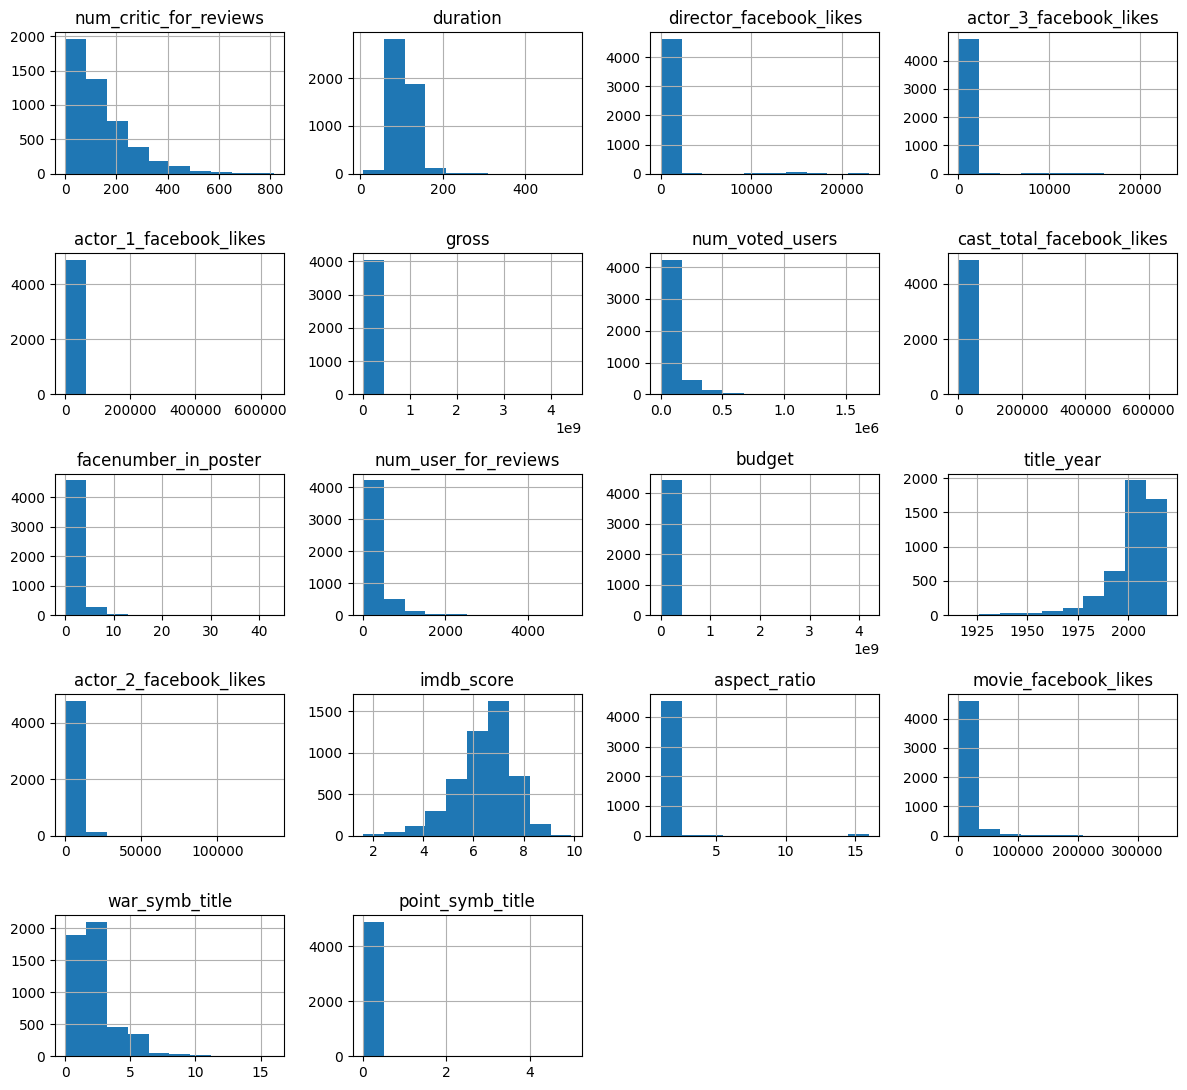

In [16]:
df.hist(figsize=(12,11))
plt.tight_layout()
plt.show()

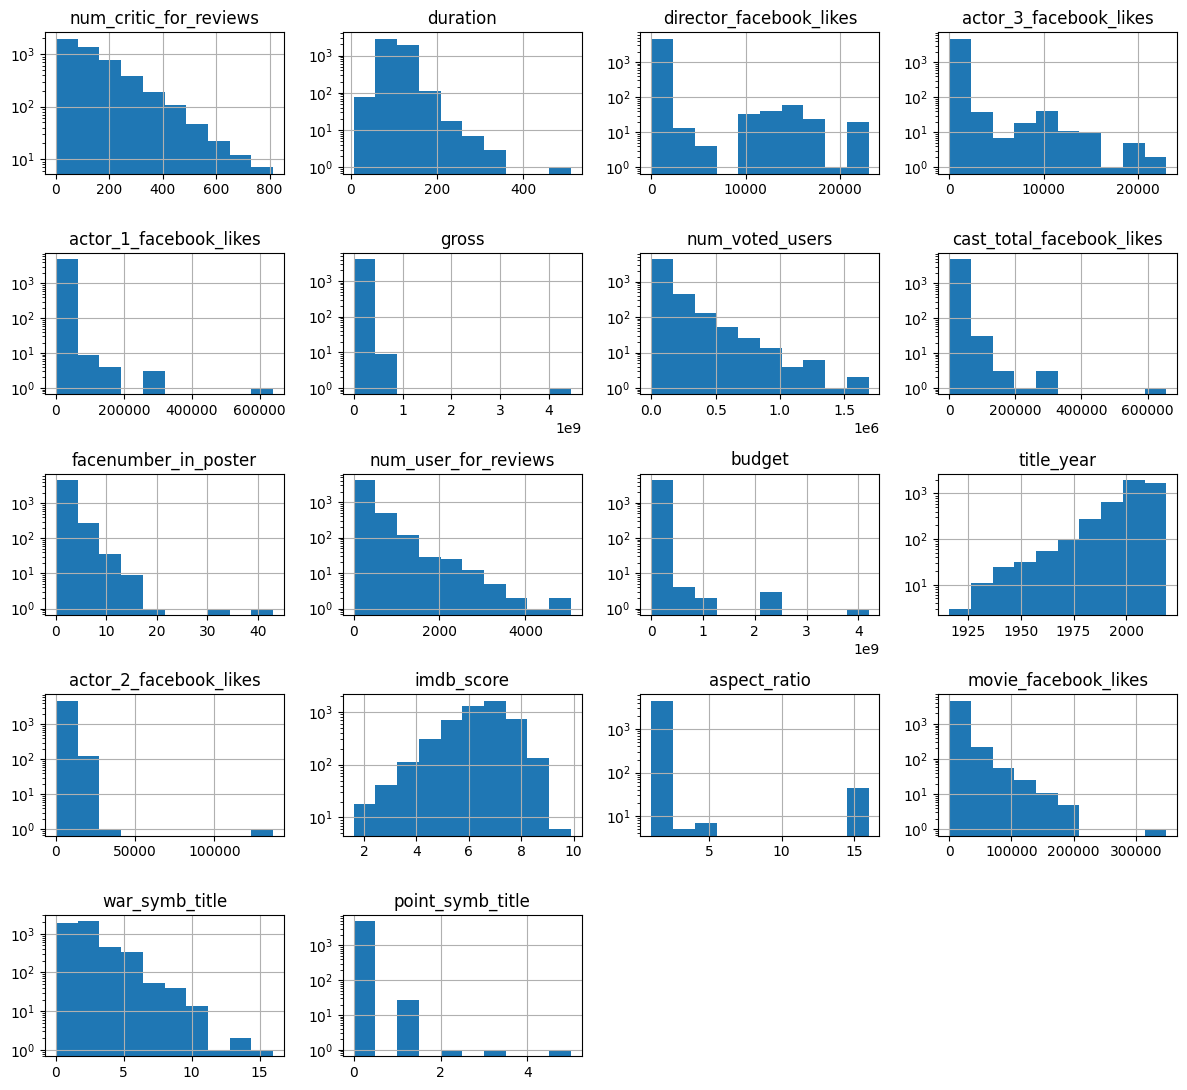

In [17]:
df.hist(figsize=(12,11), log=True)
plt.tight_layout()
plt.show()

In [18]:
# key observations:
#   - most of the feauters have right-skewed distribution -> log transformation might be used

##### 2.3.1.1 Outiler detecions

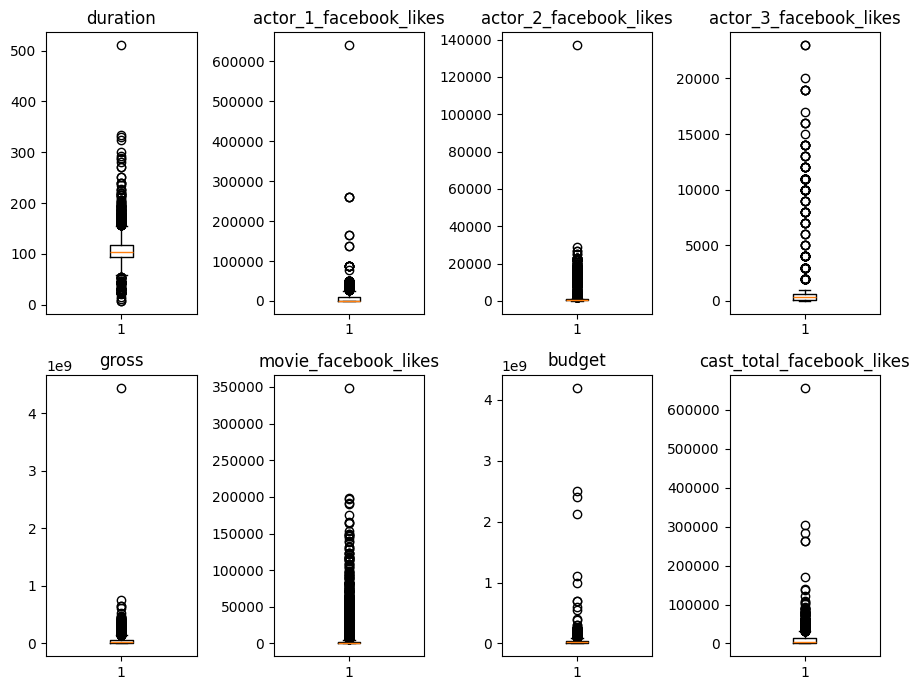

In [19]:
variables_to_check = ["duration", "actor_1_facebook_likes", "actor_2_facebook_likes", "actor_3_facebook_likes", "gross", "movie_facebook_likes", "budget", "cast_total_facebook_likes"]

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(9,7))
axes = axes.flatten()

for i, col in enumerate(variables_to_check):
    data = (df[col].dropna())
    axes[i].boxplot(data)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

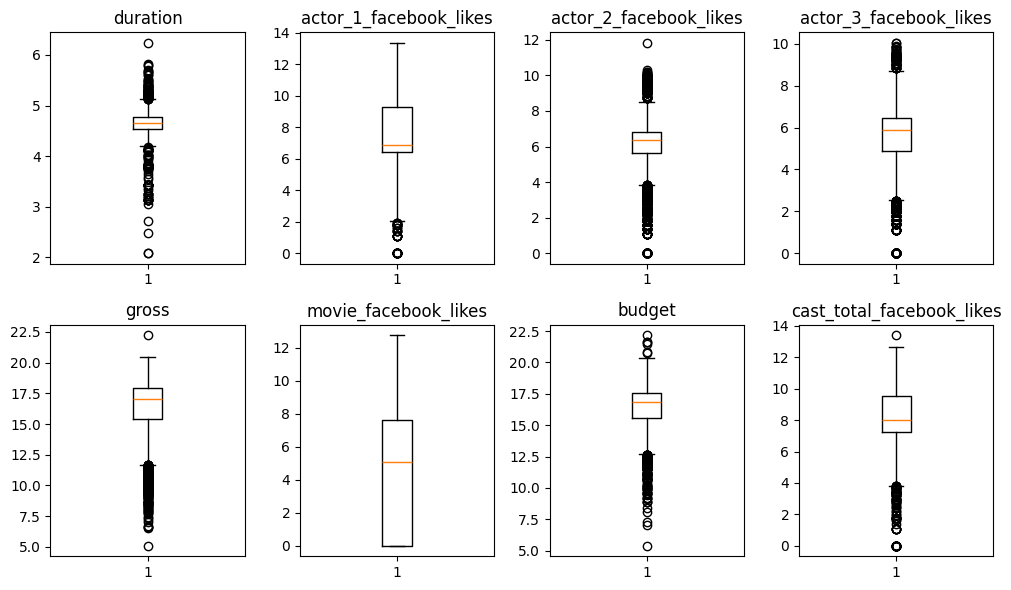

In [20]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(10,6))
axes = axes.flatten()

for i, col in enumerate(variables_to_check):
    data = np.log1p(df[col].dropna())
    axes[i].boxplot(data)
    axes[i].set_title(col)

plt.tight_layout()

In [21]:
df[df.duration>300]

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,war_symb_title,point_symb_title
1501,Color,Taylor Hackford,12.0000,330.0000,138.0000,672.0000,Jesse Borrego,848.0000,4496583.0000,Crime|Drama,Delroy Lindo,"Blood In, Blood Out",23181,3227,Raymond Cruz,2.0000,1970s|1980s|barrio|gang war|mexican,http://www.imdb.com/title/tt0106469/?ref_=fn_t...,129.0000,English,USA,R,35000000.0000,1993.0000,674.0000,8.0000,1.6600,6000,0,0
2467,Color,NaN,108.0000,334.0000,NaN,30.0000,Nora von Waldstätten,897.0000,145118.0000,Biography|Crime|Drama|Thriller,Edgar Ramírez,Carlos,10111,1032,Katharina Schüttler,0.0000,opec|pubic hair|revolutionary|terrorism|true c...,http://www.imdb.com/title/tt1321865/?ref_=fn_t...,36.0000,English,France,Not Rated,NaN,NaN,30.0000,7.7000,2.3500,0,2,0
1144,Color,Michael Cimino,102.0000,325.0000,517.0000,678.0000,Sam Waterston,12000.0000,1500000.0000,Adventure|Drama|Western,Jeff Bridges,Heaven's Gate,9830,14255,Isabelle Huppert,0.0000,1890s|hired gun|immigrant|johnson county war|s...,http://www.imdb.com/title/tt0080855/?ref_=fn_t...,189.0000,English,USA,R,44000000.0000,1980.0000,849.0000,6.8000,2.3500,1000,2,0
1710,Color,NaN,16.0000,511.0000,NaN,51.0000,Ingvar Eggert Sigurðsson,147.0000,NaN,Crime|Drama|Thriller,Ólafur Darri Ólafsson,Trapped,2308,307,Björn Hlynur Haraldsson,0.0000,coastal town|iceland|police|snowstorm|winter s...,http://www.imdb.com/title/tt3561180/?ref_=fn_t...,19.0000,Icelandic,Iceland,NaN,NaN,NaN,63.0000,8.2000,16.0000,0,2,0


In [22]:
df.loc[df.movie_title == "Blood In, Blood Out\xa0", "duration"] = 180 # true duration: 180
# the remaining rows have correct values of duration

In [23]:
df[df.actor_1_facebook_likes>250000]

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,war_symb_title,point_symb_title
1903,Color,Adam McKay,181.0000,98.0000,285.0000,7000.0000,Will Ferrell,640000.0000,84136909.0000,Comedy,Darcy Donavan,Anchorman: The Legend of Ron Burgundy,267921,656730,Steve Carell,5.0000,1970s|anchorman|news anchor|newsroom|tv station,http://www.imdb.com/title/tt0357413/?ref_=fn_t...,577.0000,English,USA,PG-13,26000000.0000,2004.0000,8000.0000,7.2000,1.8500,0,5,0
4593,Color,Johnny Remo,2.0000,112.0000,74.0000,891.0000,Randy Wayne,260000.0000,96734.0000,Action|Drama,Matthew Ziff,Hardflip,606,263584,Raquel Elizabeth Ames,3.0000,family relationships|loss of mother|san diego ...,http://www.imdb.com/title/tt1907639/?ref_=fn_t...,5.0000,English,USA,PG-13,1000000.0000,2012.0000,984.0000,5.6000,1.8500,706,2,0
4410,NaN,John Stockwell,2.0000,90.0000,134.0000,354.0000,T.J. Storm,260000.0000,NaN,Action,Matthew Ziff,Kickboxer: Vengeance,246,261818,Sam Medina,5.0000,NaN,http://www.imdb.com/title/tt3082898/?ref_=fn_t...,1.0000,NaN,USA,NaN,17000000.0000,2016.0000,454.0000,9.1000,NaN,0,2,0
4705,Color,Travis Romero,5.0000,67.0000,4.0000,2000.0000,Lorraine Ziff,260000.0000,NaN,Drama|Thriller,Matthew Ziff,Treachery,344,283939,Michael Biehn,5.0000,panties|white panties,http://www.imdb.com/title/tt2380301/?ref_=fn_t...,5.0000,English,USA,NaN,625000.0000,2013.0000,21000.0000,3.9000,NaN,0,3,0


In [24]:
df.loc[df.actor_1_name == "Matthew Ziff", "actor_1_facebook_likes"] = np.nan # facebook likes for this actor is incorret, filling in missing data

In [25]:
df[df.actor_2_facebook_likes>100000] # fake number of likes

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,war_symb_title,point_symb_title
1223,Color,David R. Ellis,221.0000,82.0000,160.0000,748.0000,Andrew Fiscella,164000.0000,66466372.0000,Horror,Krista Allen,The Final Destination,75345,303717,Shantel VanSanten,0.0000,attempted suicide|car crash|collapsing scaffol...,http://www.imdb.com/title/tt1144884/?ref_=fn_t...,290.0000,English,USA,R,40000000.0000,2009.0000,137000.0000,5.2000,2.3500,0,2,0


In [26]:
df.loc[df.actor_2_name == "Andrew Fiscella", "actor_2_facebook_likes"] = np.nan # facebook likes for this actor is incorret, filling in missing data

In [27]:
df[df.actor_3_facebook_likes>20000] # correct values

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,war_symb_title,point_symb_title
97,Color,Christopher Nolan,642.0000,148.0000,22000.0000,23000.0000,Tom Hardy,29000.0000,292568851.0000,Action|Adventure|Sci-Fi|Thriller,Leonardo DiCaprio,Inception,1468200,81115,Joseph Gordon-Levitt,0.0000,ambiguous ending|corporate espionage|dream|sub...,http://www.imdb.com/title/tt1375666/?ref_=fn_t...,2803.0000,English,USA,PG-13,160000000.0000,2010.0000,27000.0000,8.8000,2.3500,175000,0,0
3,Color,Christopher Nolan,813.0000,164.0000,22000.0000,23000.0000,Christian Bale,27000.0000,448130642.0000,Action|Thriller,Tom Hardy,The Dark Knight Rises,1144337,106759,Joseph Gordon-Levitt,0.0000,deception|imprisonment|lawlessness|police offi...,http://www.imdb.com/title/tt1345836/?ref_=fn_t...,2701.0000,English,USA,PG-13,250000000.0000,2012.0000,23000.0000,8.5000,2.3500,164000,3,0


In [28]:
df[df.gross>1000000000]

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,war_symb_title,point_symb_title
4941,Green and Yellow,Aina Obama,140.0000,108.0000,777.0000,100.0000,200,300.0000,4444444444.0000,Animation|Documentary,Unit 1,A!O!U!I!E!,35701,1488,Unit 3,3.0000,no fate| detroit| michigan| merefa| absolution...,http://www.imdb.com/title/tt2403815/?ref_=fn_t...,3.0000,Morse,Kyrgyzstan,NaN,21345000.0000,2019.0000,3.0000,9.9000,1.0000,7517,1,5


In [29]:
df = df[df.director_name != "Aina Obama"] # this movei doesn't exist, fake data

In [30]:
df[df.movie_facebook_likes>300000] # correct values

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,war_symb_title,point_symb_title
96,Color,Christopher Nolan,712.0000,169.0000,22000.0000,6000.0000,Anne Hathaway,11000.0000,187991439.0000,Adventure|Drama|Sci-Fi,Matthew McConaughey,Interstellar,928227,31488,Mackenzie Foy,1.0000,black hole|father daughter relationship|saving...,http://www.imdb.com/title/tt0816692/?ref_=fn_t...,2725.0000,English,USA,PG-13,165000000.0000,2014.0000,11000.0000,8.6000,2.3500,349000,3,0


In [31]:
df[df.budget > 1000000000]

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,war_symb_title,point_symb_title
3424,Color,Katsuhiro Ôtomo,150.0000,124.0000,78.0000,4.0000,Takeshi Kusao,6.0000,439162.0000,Action|Animation|Sci-Fi,Mitsuo Iwata,Akira,106160,28,Tesshô Genda,0.0000,based on manga|biker gang|gifted child|post th...,http://www.imdb.com/title/tt0094625/?ref_=fn_t...,430.0000,Japanese,Japan,R,1100000000.0000,1988.0000,5.0000,8.1000,1.8500,0,3,0
3006,Color,Lajos Koltai,73.0000,134.0000,45.0000,0.0000,Péter Fancsikai,9.0000,195888.0000,Drama|Romance|War,Marcell Nagy,Fateless,5603,11,Bálint Péntek,0.0000,bus|death|gay slur|hatred|jewish,http://www.imdb.com/title/tt0367082/?ref_=fn_t...,45.0000,Hungarian,Hungary,R,2500000000.0000,2005.0000,2.0000,7.1000,2.3500,607,1,0
3860,Color,Chan-wook Park,202.0000,112.0000,0.0000,38.0000,Yeong-ae Lee,717.0000,211667.0000,Crime|Drama,Min-sik Choi,Lady Vengeance,53508,907,Hye-jeong Kang,0.0000,cake|christian|lesbian sex|oral sex|pregnant s...,http://www.imdb.com/title/tt0451094/?ref_=fn_t...,131.0000,Korean,South Korea,R,4200000000.0000,2005.0000,126.0000,7.7000,2.3500,4000,2,0
2324,Color,Hayao Miyazaki,174.0000,134.0000,6000.0000,745.0000,Jada Pinkett Smith,893.0000,2298191.0000,Adventure|Animation|Fantasy,Minnie Driver,Princess Mononoke,221552,2710,Billy Crudup,0.0000,anime|cult film|forest|princess|studio ghibli,http://www.imdb.com/title/tt0119698/?ref_=fn_t...,570.0000,Japanese,Japan,PG-13,2400000000.0000,1997.0000,851.0000,8.4000,1.8500,11000,1,0
2335,Color,Katsuhiro Ôtomo,105.0000,103.0000,78.0000,101.0000,Robin Atkin Downes,488.0000,410388.0000,Action|Adventure|Animation|Family|Sci-Fi|Thriller,William Hootkins,Steamboy,13727,991,Rosalind Ayres,1.0000,19th century|ball|boy|inventor|steam,http://www.imdb.com/title/tt0348121/?ref_=fn_t...,79.0000,Japanese,Japan,PG-13,2127519898.0000,2004.0000,336.0000,6.9000,1.8500,973,1,0


In [32]:
# the high budget value is ture, but it's local currency

In [33]:
df[df.budget > 100000000].country.value_counts()
# country with much cheaper currency than USD: India, Japan, Thailand, Hungary, South Korea.

country
USA            246
UK              18
Australia        5
India            5
Japan            4
France           4
Germany          3
Thailand         3
New Zealand      2
China            2
Canada           2
Hungary          1
South Korea      1
Spain            1
Name: count, dtype: int64

In [34]:
rates_data = [
    {"country": "Hungary", "title_year": 2005, "currency_ratio": 199.6},
    {"country": "Hungary", "title_year": 2011, "currency_ratio": 200.9}, 
    {"country": "India", "title_year": 1998, "currency_ratio": 41.3},
    {"country": "India", "title_year": 2000, "currency_ratio": 44.9},
    {"country": "India", "title_year": 2001, "currency_ratio": 47.2},
    {"country": "India", "title_year": 2004, "currency_ratio": 45.3},
    {"country": "India", "title_year": 2005, "currency_ratio": 44.1},
    {"country": "India", "title_year": 2006, "currency_ratio": 45.3},
    {"country": "India", "title_year": 2007, "currency_ratio": 41.3},
    {"country": "India", "title_year": 2008, "currency_ratio": 43.5},
    {"country": "India", "title_year": 2009, "currency_ratio": 48.4},
    {"country": "India", "title_year": 2010, "currency_ratio": 45.7},
    {"country": "India", "title_year": 2011, "currency_ratio": 46.6},
    {"country": "India", "title_year": 2012, "currency_ratio": 53.4},
    {"country": "India", "title_year": 2013, "currency_ratio": 58.5},
    {"country": "India", "title_year": 2014, "currency_ratio": 61.0},
    {"country": "India", "title_year": 2015, "currency_ratio": 64.1},
    {"country": "India", "title_year": 2016, "currency_ratio": 67.2},
    {"country": "Japan", "title_year": 1954, "currency_ratio": 360.0},
    {"country": "Japan", "title_year": 1970, "currency_ratio": 360.0},
    {"country": "Japan", "title_year": 1988, "currency_ratio": 128.1},
    {"country": "Japan", "title_year": 1993, "currency_ratio": 111.1},
    {"country": "Japan", "title_year": 1994, "currency_ratio": 102.2},
    {"country": "Japan", "title_year": 1995, "currency_ratio": 94.0},
    {"country": "Japan", "title_year": 1997, "currency_ratio": 121.0},
    {"country": "Japan", "title_year": 1999, "currency_ratio": 113.9},
    {"country": "Japan", "title_year": 2000, "currency_ratio": 107.8},
    {"country": "Japan", "title_year": 2001, "currency_ratio": 121.5},
    {"country": "Japan", "title_year": 2004, "currency_ratio": 108.2},
    {"country": "Japan", "title_year": 2008, "currency_ratio": 103.4},
    {"country": "Japan", "title_year": 2010, "currency_ratio": 87.8},
    {"country": "Japan", "title_year": 2013, "currency_ratio": 97.6},
    {"country": "Japan", "title_year": 2015, "currency_ratio": 121.0},
    {"country": "Japan", "title_year": 2016, "currency_ratio": 108.8},
    {"country": "South Korea", "title_year": 1981, "currency_ratio": 681.0},
    {"country": "South Korea", "title_year": 2003, "currency_ratio": 1191.0},
    {"country": "South Korea", "title_year": 2004, "currency_ratio": 1145.0},
    {"country": "South Korea", "title_year": 2005, "currency_ratio": 1024.0},
    {"country": "South Korea", "title_year": 2007, "currency_ratio": 929.0},
    {"country": "South Korea", "title_year": 2008, "currency_ratio": 1102.0},
    {"country": "South Korea", "title_year": 2009, "currency_ratio": 1276.0},
    {"country": "South Korea", "title_year": 2010, "currency_ratio": 1156.0},
    {"country": "South Korea", "title_year": 2013, "currency_ratio": 1094.0},
    {"country": "South Korea", "title_year": 2014, "currency_ratio": 1053.0},
    {"country": "South Korea", "title_year": 2016, "currency_ratio": 1160.0}
]

currency_df = pd.DataFrame(rates_data)
df = pd.merge(df, currency_df, on=["country", "title_year"], how="left")
mask = df['currency_ratio'].notnull()
df.loc[mask, "budget"] = df.loc[mask, "budget"] / df.loc[mask, "currency_ratio"]
df.drop("currency_ratio", axis=1, inplace=True)
df[df.country == "Japan"].head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,war_symb_title,point_symb_title
208,Color,Katsuhiro Ôtomo,150.0000,124.0000,78.0000,4.0000,Takeshi Kusao,6.0000,439162.0000,Action|Animation|Sci-Fi,Mitsuo Iwata,Akira,106160,28,Tesshô Genda,0.0000,based on manga|biker gang|gifted child|post th...,http://www.imdb.com/title/tt0094625/?ref_=fn_t...,430.0000,Japanese,Japan,R,8587041.3739,1988.0000,5.0000,8.1000,1.8500,0,3,0
1512,Color,Takao Okawara,107.0000,99.0000,2.0000,3.0000,Naomi Nishida,43.0000,10037390.0000,Action|Adventure|Drama|Sci-Fi|Thriller,Hiroshi Abe,Godzilla 2000,5442,53,Sakae Kimura,0.0000,godzilla|kaiju|monster|orga|ufo,http://www.imdb.com/title/tt0188640/?ref_=fn_t...,140.0000,Japanese,Japan,PG,8779631.2555,1999.0000,3.0000,6.0000,2.3500,339,1,0
1513,Color,Hideaki Anno,1.0000,120.0000,28.0000,12.0000,Shin'ya Tsukamoto,544.0000,NaN,Action|Adventure|Drama|Horror|Sci-Fi,Mark Chinnery,Godzilla Resurgence,374,699,Atsuko Maeda,0.0000,blood|godzilla|monster|sequel,http://www.imdb.com/title/tt4262980/?ref_=fn_t...,13.0000,Japanese,Japan,NaN,NaN,2016.0000,106.0000,8.2000,2.3500,0,3,0
1615,Color,Shinji Aramaki,62.0000,115.0000,21.0000,47.0000,Yû Aoi,173.0000,NaN,Adventure|Animation|Sci-Fi,Shun Oguri,Harlock: Space Pirate,8227,386,Haruma Miura,0.0000,liberty|space adventure|space opera|time trave...,http://www.imdb.com/title/tt2668134/?ref_=fn_t...,28.0000,Japanese,Japan,Not Rated,307377.0492,2013.0000,59.0000,6.5000,2.3500,0,5,0
1767,Color,Hayao Miyazaki,212.0000,119.0000,6000.0000,422.0000,Blythe Danner,23000.0000,4710455.0000,Adventure|Animation|Family|Fantasy,Christian Bale,Howl's Moving Castle,214091,24263,Jean Simmons,0.0000,anime|castle|demon|steampunk|witch,http://www.imdb.com/title/tt0347149/?ref_=fn_t...,330.0000,Japanese,Japan,PG,221811.4603,2004.0000,713.0000,8.2000,1.8500,13000,2,0


In [35]:
df[df.cast_total_facebook_likes > 500000] # correct values

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,war_symb_title,point_symb_title
310,Color,Adam McKay,181.0000,98.0000,285.0000,7000.0000,Will Ferrell,640000.0000,84136909.0000,Comedy,Darcy Donavan,Anchorman: The Legend of Ron Burgundy,267921,656730,Steve Carell,5.0000,1970s|anchorman|news anchor|newsroom|tv station,http://www.imdb.com/title/tt0357413/?ref_=fn_t...,577.0000,English,USA,PG-13,26000000.0000,2004.0000,8000.0000,7.2000,1.8500,0,5,0


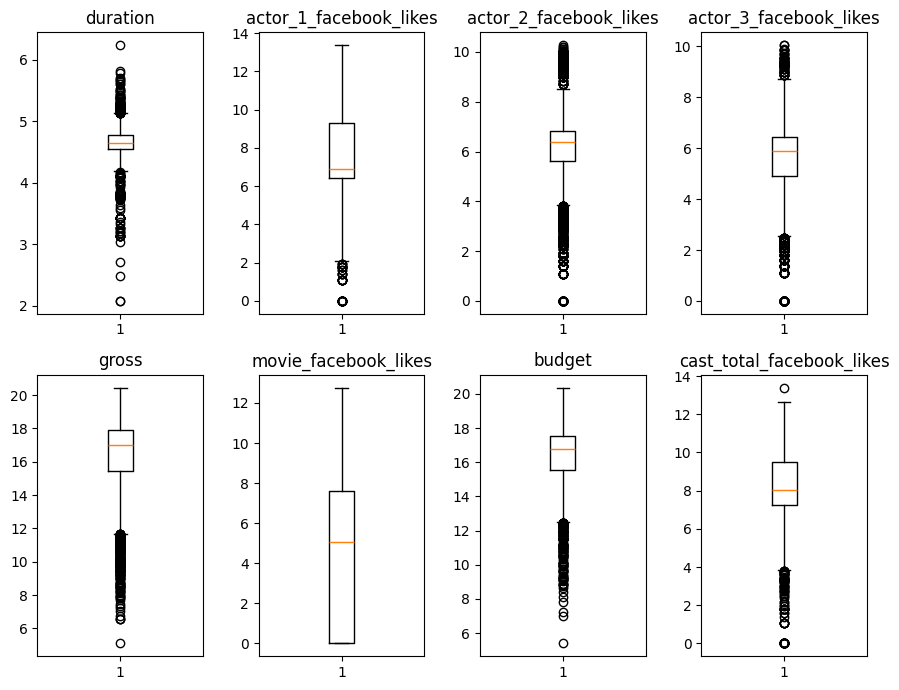

In [36]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(9,7))
axes = axes.flatten()

for i, col in enumerate(variables_to_check):
    data = np.log1p((df[col].dropna()))
    axes[i].boxplot(data)
    axes[i].set_title(col)

plt.tight_layout()

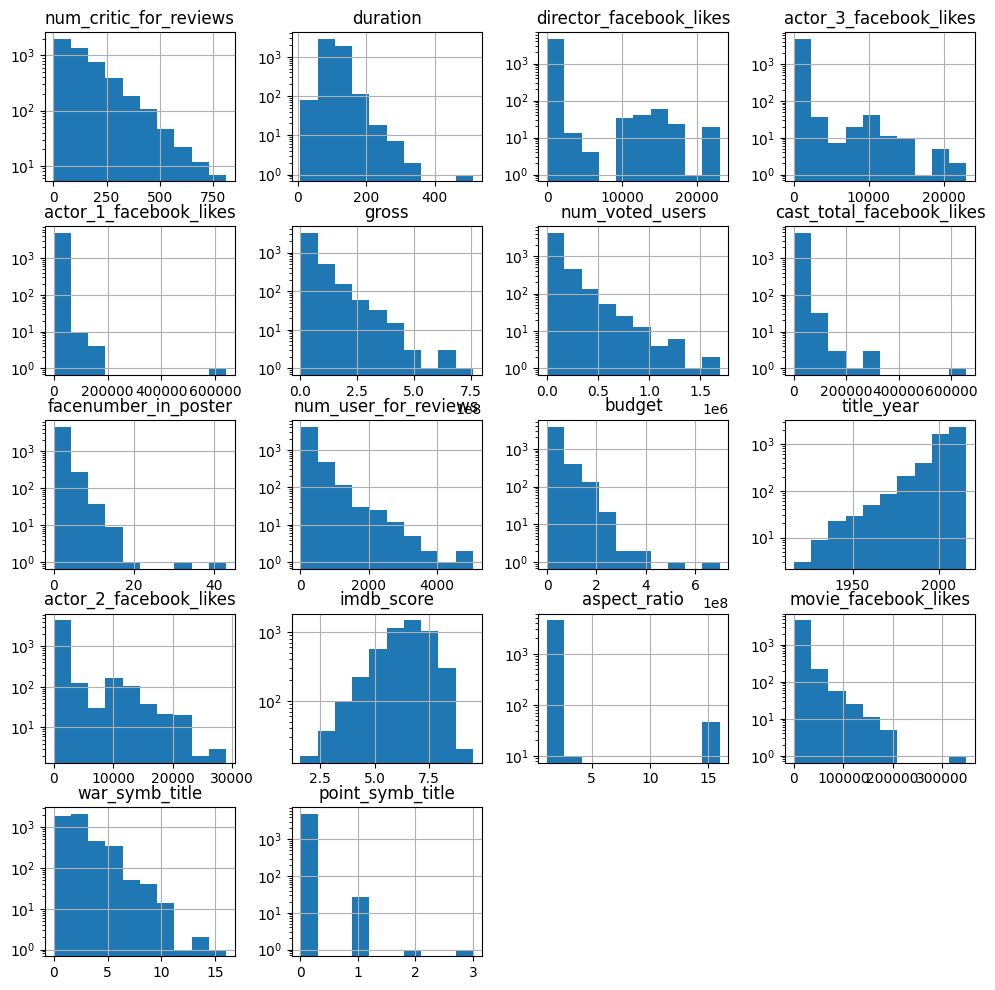

In [37]:
df.hist(figsize=(12,12), log=True)
plt.tight_layout
plt.show()

#### 2.3.2 Categorical features

In [38]:
df.loc[:, str_feauteres].nunique().sort_values(ascending=False)

movie_title        4916
movie_imdb_link    4916
plot_keywords      4757
actor_3_name       3518
actor_2_name       3029
director_name      2397
actor_1_name       2095
genres              913
country              65
language             46
content_rating       18
color                 2
dtype: int64

In [39]:
df.aspect_ratio.nunique() # it's also categorical feature (discrete screen formats)

22

### 2.4 Correlation

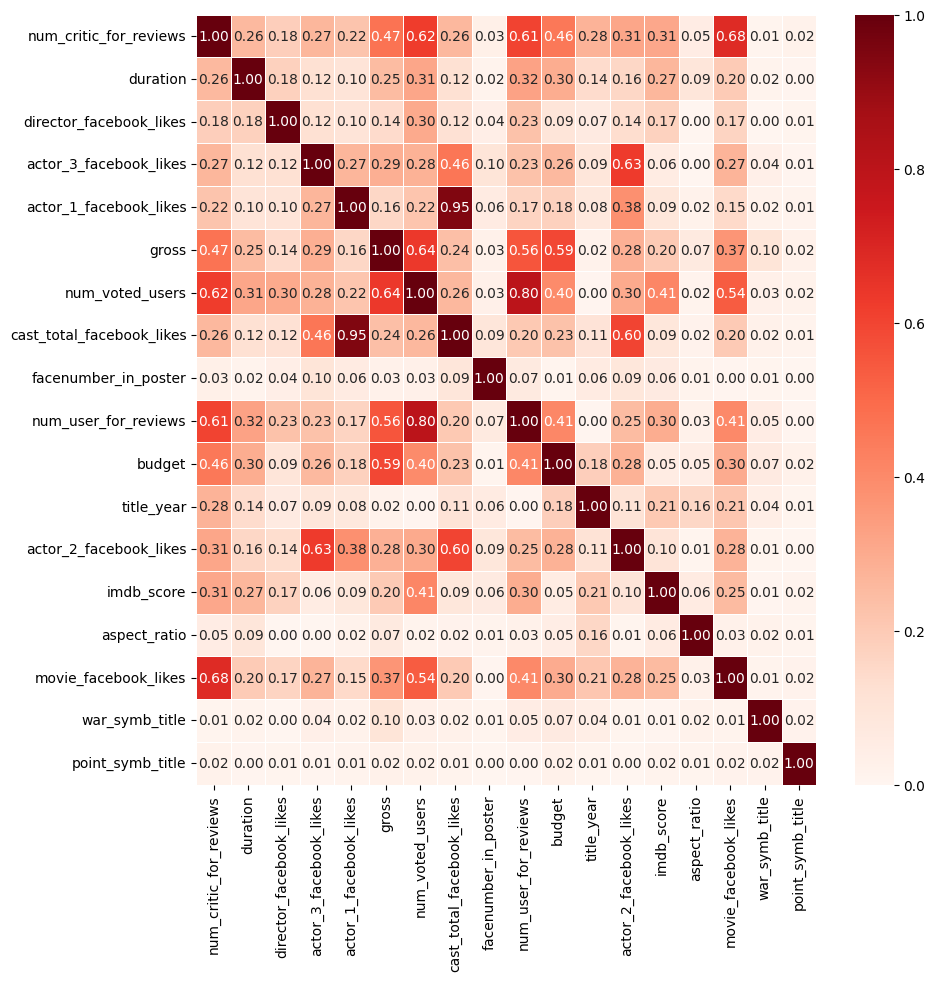

In [40]:
cor = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(10,10))
sns.heatmap(abs(cor), cmap='Reds',annot=True, fmt=".2f",vmin=0, linewidths=0.7)
plt.show()

In [41]:
# cast_total_facebook_light is obviously highly correleted with actor_1/2_facebook_likes -> drop cast_total_facebook_likes
# num_users_for_reviews is highy corelated with num_voted_users -> creating new feature based on them
# gross is the most corealted with num_voted_users, num_user_for_reviews and num_critic_for_reviews - > these features might be crucial in prediciting gross

In [42]:
df = df.drop("cast_total_facebook_likes", axis = 1)

In [43]:
# potential new feature:
df.num_user_for_reviews / df.num_voted_users

0      0.0271
1      0.0035
2      0.0318
3      0.0025
4         NaN
        ...  
4911   0.0028
4912   0.0068
4913   0.0041
4914   0.0052
4915   0.0048
Length: 4916, dtype: float64

### 2.5 Feature engineering

In [44]:
features = ["country", "language", "content_rating", "aspect_ratio", "color"]
summary_list = []

for feature in features:
    top5 = df[feature].value_counts().head(8).reset_index()
    top5.columns = [f"{feature}_value", f"count_{feature}"]
    summary_list.append(top5)

df_top_values = pd.concat(summary_list, axis=1)
df_top_values

,country_value,count_country,language_value,count_language,content_rating_value,count_content_rating,aspect_ratio_value,count_aspect_ratio,color_value,count_color
0,USA,3711,English,4582,R,2067,2.3500,2283,Color,4693.0000
1,UK,434,French,73,PG-13,1411,1.8500,1867,Black and White,204.0000
2,France,154,Spanish,40,PG,686,1.7800,108,NaN,NaN
3,Canada,122,Hindi,28,Not Rated,115,1.3700,99,NaN,NaN
4,Germany,94,Mandarin,24,G,112,1.3300,66,NaN,NaN
5,Australia,53,German,19,Unrated,59,1.6600,63,NaN,NaN
6,India,34,Japanese,17,Approved,54,16.0000,45,NaN,NaN
7,Spain,33,Cantonese,11,TV-14,29,2.3900,15,NaN,NaN


In [45]:
# new feature:
# country -> is_USA
# language -> is_englisg
# content_ratio -> is_R, is_PG-13, is_PG, is_Unrated (Not Rated, Unrated)
# aspect_ratio -> aspect_ratio
# color -> is_color

In [46]:
# other ideas:
# actor_1/2/3_name -> actor_count
# director_name -> director_count
# genres -> genres_mean_target (target encoding)
# plot_keywords -> plot_keywords_mean_target (target encoding)
# num_user_for_reviews / num_voted_users -> review_ratio

In [47]:
class PrepareData(BaseEstimator, TransformerMixin):
    def __init__(self, min_count=10, regression_task = True):

        self.min_count = min_count

        self.top_ratings = ['R', 'PG-13', 'PG', 'G', 'Unrated']
        self.unrated_names = ['Unrated', 'Not Rated']

        self.top_aspect_ratio = [1.85, 2.35]
        self.regression_task = regression_task
    
    def _calculate_means(self, feature_data, y):
        """
        target encoding for pipe-separated categories
        """
        df_tmp = pd.DataFrame({'x': feature_data, 'y': y})
        df_tmp['x'] = df_tmp.x.fillna("Unknown").str.split("|")
        df_tmp = df_tmp.explode('x')

        counts = df_tmp.x.value_counts()
        valid_category = counts[counts >= self.min_count].index

        df_filtered = df_tmp[df_tmp.x.isin(valid_category)]

        means = df_filtered.groupby("x")["y"].mean().to_dict()

        global_mean = np.mean(y)

        return means, global_mean
    
    def _create_new_feature(self, feature_data, means_dict, global_mean):
        """
        maps text categories to target means
        """
        result =  feature_data.fillna("Unknown").str.split("|").explode().map(means_dict).fillna(global_mean).groupby(level=0).mean()
        return result.reindex(feature_data.index).fillna(global_mean)
    
    def _calc_combo(self, genres_str):
        """
        calculate average budget for combined movie genres
        """
        if pd.isna(genres_str):
            return self.global_budget_median_
        
        genres = genres_str.split("|")
        vals = []
        for g in genres:
            val = self.genre_budget_medians_.get(g, self.global_budget_median_)
            if pd.isna(val): 
                val = self.global_budget_median_
            vals.append(val)        
        return np.mean(vals)
    
    def fit(self,X,y):
        # non-numerical data
        if not self.regression_task: 
            y= X['imdb_score']
            
        self.means_genres_, self.global_mean_genres_ = self._calculate_means(X.genres, y)
        self.means_keywords_, self.global_mean_keywords_ = self._calculate_means(X.plot_keywords, y)

        self.actor_counts_ = pd.concat([X.actor_1_name, X.actor_2_name, X.actor_3_name]).dropna().value_counts()
        self.director_counts_ = X.director_name.dropna().value_counts()

        df_budget = pd.DataFrame({'genres': X.genres, 'budget': X.budget})
        df_budget['genres'] = df_budget.genres.fillna("Unknown").str.split("|")
        df_budget = df_budget.explode("genres")

        self.genre_budget_medians_ = df_budget.groupby('genres')['budget'].median().to_dict()
        self.global_budget_median_ = df_budget['budget'].median()

        return self 

    def transform(self, X):
        X_copy = X.copy()
        
        # missing values
        X_copy["is_missing_budget"] = X_copy['budget'].isna().astype(int)
        X_copy.loc[X_copy['budget'].isna(),'budget'] = X_copy.loc[X_copy['budget'].isna(), 'genres'].apply(self._calc_combo)

        X_copy["is_missing_rating"] = X_copy.content_rating.isna().astype(int)
        X_copy.loc[X_copy.content_rating.isna(), "content_rating"] = "Unrated"

        X_copy["num_user_for_reviews"] = X_copy["num_user_for_reviews"].fillna(0)
        X_copy["num_critic_for_reviews"] = X_copy["num_critic_for_reviews"].fillna(0)
        
        # creating new features
        X_copy["genres_mean_target"] = self._create_new_feature(X.genres, self.means_genres_, self.global_mean_genres_)
        X_copy["plot_keywords_mean_target"] = self._create_new_feature(X.plot_keywords, self.means_keywords_, self.global_mean_keywords_)
        
        X_copy["actor_counts"] = X.actor_1_name.map(self.actor_counts_).fillna(0) + X.actor_2_name.map(self.actor_counts_).fillna(0) + X.actor_3_name.map(self.actor_counts_).fillna(0)
        X_copy["director_counts"] = X.director_name.map(self.director_counts_).fillna(0)

        X_copy["is_USA"] = (X_copy.country == "USA").astype(int)
        X_copy["is_english"] = (X_copy.language == "English").astype(int)

        X_copy.content_rating = X_copy.content_rating.replace(self.unrated_names, "Unrated")

        for rating in self.top_ratings:
            X_copy[f"is_rating_{rating}"] = (X_copy.content_rating == rating).astype(int)

        for ratio in self.top_aspect_ratio:
            X_copy[f"is_aspect_ratio_{ratio}"] = (X_copy.aspect_ratio == ratio).astype(int)
        
        X_copy[f"is_color"] = (X_copy.color == "Color").astype(int)

        X_copy["review_ratio"] = (X_copy["num_user_for_reviews"] / X_copy["num_voted_users"])

        X_copy = X_copy.drop(["genres", "plot_keywords", "actor_1_name", "actor_2_name", "actor_3_name", "director_name", "country", "language", "color", "num_user_for_reviews", "num_voted_users", "content_rating", "aspect_ratio"],axis=1)
        if not self.regression_task:
            X_copy = X_copy.drop(["imdb_score"], axis=1)

        return X_copy

## 3. Regression task - predict the gorss value

In [48]:
X = df[~df.gross.isna()].drop("gross",axis =1) # we drop rows with missing gross value
y = np.log(df[~df.gross.isna()].gross) # log transformation

rnd_state = 123

# 60% train, 20% valid, 20% test
x_temp, x_test, y_temp, y_test = train_test_split(X, y,test_size=0.2, random_state=rnd_state)
x_train, x_valid, y_train, y_valid = train_test_split(x_temp, y_temp, test_size=0.25, random_state=rnd_state)
x_combined = pd.concat([x_train, x_valid])
y_combined = pd.concat([y_train, y_valid])

In [49]:
def evaluate_model(y_true, y_pred, regression_task = True):
    if regression_task:
        y_true_exp = np.exp(y_true)
        y_pred_exp = np.exp(y_pred)

        rmsle = root_mean_squared_log_error(y_true_exp, y_pred_exp) # misestimation: exp(rsmle) - 1
        mae = mean_absolute_error(y_true_exp, y_pred_exp)
        rmse = root_mean_squared_error(y_true_exp, y_pred_exp)

        print(f"RMSLE = {round(rmsle,4)}\nMAE = {round(mae,4)}\nrmse = {round(rmse,4)}")
        
        return {'rmsle': rmsle, 'mae': mae, 'rmse': rmse}
    
    # classification 
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    
    print("F1_score: ", round(f1,3), "\nPrecision_score: ", round(precision, 3), "\nBalanced_accuracy: ", round(bal_acc, 3))

    return {"F1": f1, "Precision":precision, "Balanced_accuracy": bal_acc}
        

def plot_learning_curve(pipeline, x,y, regression_task=True):
    if regression_task:
        train_size, train_score, valid_score = learning_curve(pipeline,x,y,train_sizes=np.linspace(0.1,1,10), cv = 3, scoring='neg_root_mean_squared_error', n_jobs=-1)
        train_score = -train_score
        valid_score = -valid_score
    else:
        train_size, train_score, valid_score = learning_curve(pipeline,x,y,train_sizes=np.linspace(0.1,1,10), cv = 3, scoring='f1', n_jobs=-1, error_score='raise')
    train_mean = np.mean(train_score,axis=1)
    train_std = np.std(train_score, axis=1)
    valid_mean = np.mean(valid_score,axis=1)
    valid_std = np.std(valid_score, axis=1)

    plt.figure(figsize=(5,5))
    plt.plot(train_size, train_mean, label="train set")
    plt.fill_between(train_size, train_mean - train_std, train_mean + train_std, alpha = 0.1)
    plt.plot(train_size, valid_mean, label="valid set")
    plt.fill_between(train_size, valid_mean - valid_std, valid_mean + valid_std, alpha = 0.1)
    plt.legend()
    plt.grid()
    plt.title('Learning curve')
    plt.xlabel('Training set size')
    if regression_task:
        plt.ylabel('RMSLE')
    else:
        plt.ylabel('F1_score')
    plt.show()

def plot_validation_curve(pipeline,x,y,params, regression_task=True):
    n_params = len(params)
    cols = 3
    rows = int(np.ceil(n_params/cols))

    fig, axes = plt.subplots(nrows=rows,ncols=cols, figsize =(10,3*rows))
    axes = axes.flatten()

    for i, (p_name, p_range) in enumerate(params.items()):
        if regression_task:
            train_score, valid_score = validation_curve(pipeline,x,y, param_name=p_name, param_range=p_range, cv=3, scoring='neg_root_mean_squared_error')
            train_score = -train_score
            valid_score = -valid_score
        else:
            train_score, valid_score = validation_curve(pipeline,x,y, param_name=p_name, param_range=p_range, cv=3, scoring='f1', error_score='raise')

        train_mean = np.mean(train_score,axis=1)
        valid_mean = np.mean(valid_score,axis=1)

        ax = axes[i]
        if regression_task:
            ax.plot(p_range, train_mean, label="Train data error")
            ax.plot(p_range, valid_mean, label="Valid data error")
            ax.set_ylabel('error')
        else: 
            ax.plot(p_range, train_mean, label="Train data score")
            ax.plot(p_range, valid_mean, label="Valid data score")
            ax.set_ylabel('score')
            
        ax.set_title(p_name.split('__')[-1])
        ax.legend()
        ax.set_xlabel('param value')

    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()

def my_mae(y_ture, y_pred):
    return mean_absolute_error(np.exp(y_ture), np.exp(y_pred))

def my_rmse(y_ture, y_pred):
    return root_mean_squared_error(np.exp(y_ture), np.exp(y_pred))

mae_scorer = make_scorer(my_mae, greater_is_better=False)
rmse_scorer = make_scorer(my_rmse, greater_is_better=False)

### 3.1 Baseline

RMSLE = 1.5743
MAE = 42524223.3753
rmse = 135849712.0994


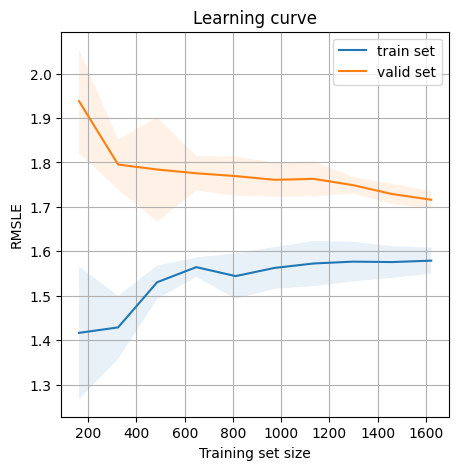

In [50]:
baseline_pipeline = Pipeline([('preprocess', PrepareData()),('imputer', SimpleImputer(strategy="most_frequent")), ('lr_model', LinearRegression())])
baseline_pipeline.fit(x_train.drop(["movie_title", "movie_imdb_link"],axis=1), y_train)
y_pred = baseline_pipeline.predict(x_valid.drop(["movie_title", "movie_imdb_link"],axis=1))
baseline_performance = evaluate_model(y_valid, y_pred)
plot_learning_curve(baseline_pipeline,x_train.drop(["movie_title", "movie_imdb_link"],axis=1), y_train)

### 3.2 Hyperparameter tuning

#### 3.2.1 HistGradientBossting

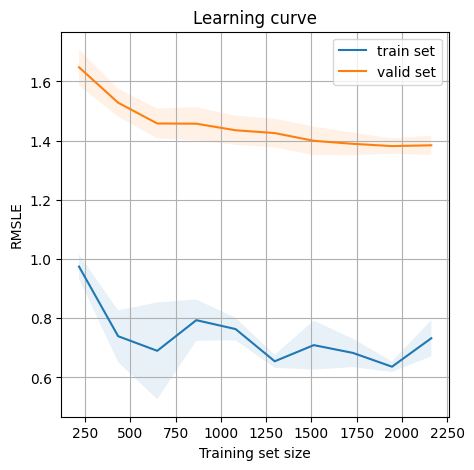

In [51]:
gb = HistGradientBoostingRegressor(random_state=rnd_state, early_stopping=True, n_iter_no_change=15)
gb_pipeline = Pipeline([("preprocessing", PrepareData()), ("model", gb)])
plot_learning_curve(gb_pipeline,x_combined.drop(["movie_title", "movie_imdb_link"],axis=1), y_combined)

##### 3.2.1.1 RandomSearch

In [52]:
# gb_params_space = {
#     'model__learning_rate': loguniform(0.001, 1),
#     'model__max_depth': [3, 4,3, 5,7,8,9],
#     'model__min_samples_leaf': randint(10,30),
#     'model__l2_regularization': loguniform(1, 100),
#     'model__max_bins': [200,150,100]
# }
# gb_rs = RandomizedSearchCV(gb_pipeline, param_distributions=gb_params_space, n_iter=1000, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1, random_state=rnd_state)
# gb_rs.fit(x_train.drop(["movie_title", "movie_imdb_link"], axis=1), y_train)
# gb_best = gb_rs.best_estimator_
# gb_rs.best_params_
# gb_pred = gb_rs.predict(x_valid.drop(["movie_title", "movie_imdb_link"], axis=1))
# gb_performance = evaluate_model(y_valid, gb_pred)

##### 3.2.1.2 Bayesian optimaization

In [ ]:
def objective(trial):
    param_space = {
        'model__learning_rate': trial.suggest_float('model__learning_rate', 0.001, 10, log=True),
        'model__max_depth': trial.suggest_int('model__max_depth', 3, 50),
        'model__min_samples_leaf': trial.suggest_int('model__min_samples_leaf', 10, 60),
        'model__l2_regularization': trial.suggest_float('model__l2_regularization', 0.001, 10, log=True),
        'model__max_bins': trial.suggest_categorical('model__max_bins', [100, 150, 200, 255]),
        'model__max_iter': trial.suggest_int('model__max_iter', 50,200)
    }

    gb_pipeline.set_params(**param_space)
    scores = cross_val_score(gb_pipeline, x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined, cv=3, scoring='neg_root_mean_squared_error',n_jobs=-1)
    return -scores.mean()

sampler_gb = TPESampler(seed=rnd_state)
study_gb = optuna.create_study(direction='minimize', sampler=sampler_gb)
study_gb.optimize(objective, n_trials=200)
gb_pipeline.set_params(**study_gb.best_params)
print("RMSLE:", study_gb.best_value)
print("Best hyperparameters", study_gb.best_params)

RMSE: 1.3636811272330827
Best parameters {'model__learning_rate': 0.08392367812661068, 'model__max_depth': 22, 'model__min_samples_leaf': 16, 'model__l2_regularization': 4.367208973767766, 'model__max_bins': 200, 'model__max_iter': 192}


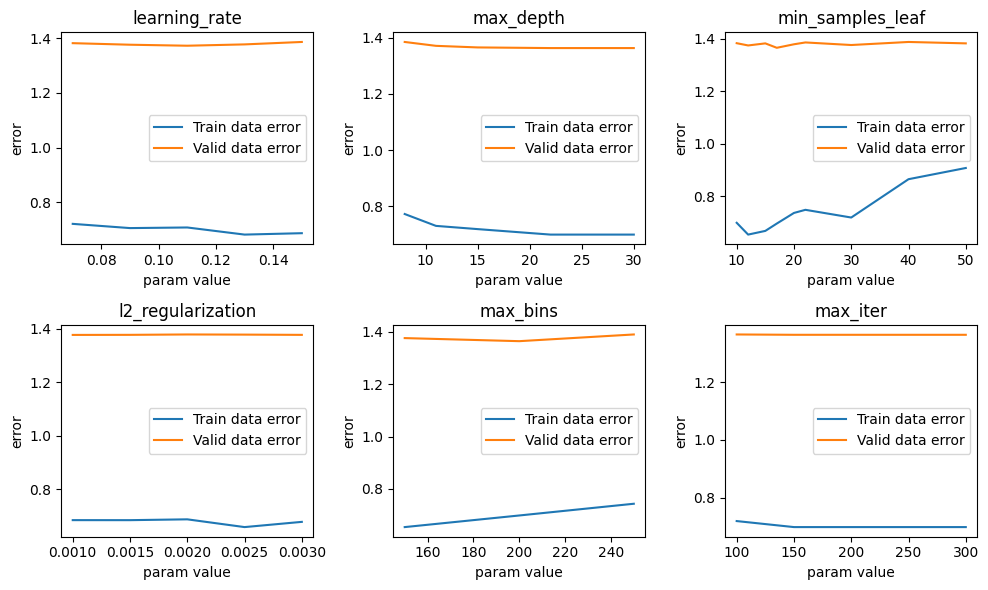

In [54]:
gb_params_vc = {
    'model__learning_rate': np.linspace(0.07, 0.15, 5), 
    'model__max_depth': [8,11,15,22,25,30],         
    'model__min_samples_leaf': [10,12,15,17, 20, 22, 30, 40, 50],
    'model__l2_regularization': np.linspace(0.001,0.003, 5),
    'model__max_bins': [150, 200,250],
    'model__max_iter': [100,150,180,192,210,240,300]           
}
plot_validation_curve(gb_pipeline, x_combined.drop(["movie_title", "movie_imdb_link"],axis=1), y_combined, gb_params_vc)

Fitting 3 folds for each of 378 candidates, totalling 1134 fits
Best params: {'model__max_bins': 190, 'model__max_depth': 13, 'model__min_samples_leaf': 18}
RMSE: 1.3885679653813832


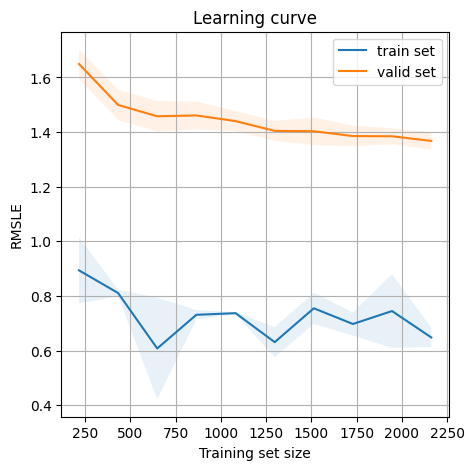

In [ ]:
param_grid = {
    'model__max_depth': [10,11,12,13,14,15,16,18,12],        
    'model__min_samples_leaf': [10,12,14,16,18,20],
    'model__max_bins': [150,180,190,200,210,220,240] 
}

cv_folds = KFold(n_splits=3, shuffle=True, random_state=rnd_state)
gb_grid = GridSearchCV(gb_pipeline, param_grid, cv=cv_folds, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
gb_grid.fit(x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined)
gb_final_model = gb_grid.best_estimator_

print("Best hyperparameters:", gb_grid.best_params_)
print("RMSLE:", -gb_grid.best_score_)
plot_learning_curve(gb_final_model,x_combined.drop(["movie_title", "movie_imdb_link"],axis=1), y_combined)

In [56]:
gb_results = cross_validate(gb_final_model, x_combined.drop(["movie_title", "movie_imdb_link"],axis=1), y_combined, cv=cv_folds, scoring = {'rmsle': 'neg_root_mean_squared_error', 'mae': mae_scorer, 'rmse': rmse_scorer})
gb_performance = {'rmsle': -gb_results['test_rmsle'].mean(), 'mae': -gb_results['test_mae'].mean(), 'rmse': -gb_results['test_rmse'].mean()}
gb_performance

{'rmsle': np.float64(1.3885679653813832),
 'mae': np.float64(23507298.933845792),
 'rmse': np.float64(43010330.00910087)}

#### 3.2.2 RandomForest

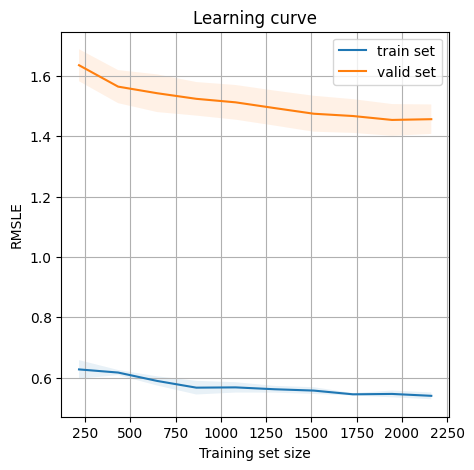

In [57]:
rf = RandomForestRegressor(random_state=rnd_state)
rf_pipeline = Pipeline([("preprocessing", PrepareData()), ("model", rf)])
plot_learning_curve(rf_pipeline, x_combined.drop(["movie_title", "movie_imdb_link"],axis=1), y_combined)

In [ ]:
def objective_rf(trial):
    param_space = {
        'model__n_estimators': trial.suggest_int('model__n_estimators', 10,500),
        'model__max_depth': trial.suggest_int('model__max_depth', 3, 40),
        'model__min_samples_leaf': trial.suggest_int('model__min_samples_leaf', 3, 100),
        'model__max_samples': trial.suggest_categorical('model__max_samples', [0.5, 0.75, 0.9]),
        'model__max_features': trial.suggest_categorical('model__max_features', [1.0, 'sqrt', 'log2'])
    }

    rf_pipeline.set_params(**param_space)
    scores = cross_val_score(rf_pipeline, x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined, cv=3, scoring='neg_root_mean_squared_error',n_jobs=-1)

    return -scores.mean()

sampler_rf = TPESampler(seed=rnd_state)
study_rf = optuna.create_study(direction='minimize',sampler=sampler_rf)
study_rf.optimize(objective_rf, n_trials=60)
rf_pipeline.set_params(**study_rf.best_params)

print("RMLSE:", study_rf.best_value)
print("Best hyperparameters", study_rf.best_params)

RMSE: 1.4477561091554414
Best parameters {'model__n_estimators': 267, 'model__max_depth': 38, 'model__min_samples_leaf': 3, 'model__max_samples': 0.9, 'model__max_features': 1.0}


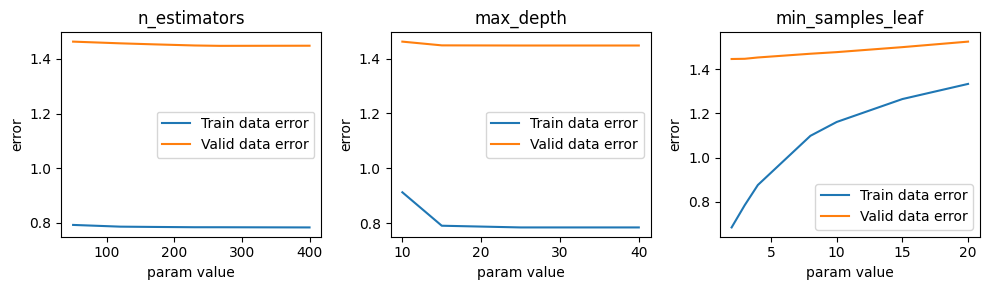

In [59]:
rf_params_vc = {
    'model__n_estimators': [50,120,170,230,267,400], 
    'model__max_depth': [10,15,25,35,38,40],         
    'model__min_samples_leaf': [2,3,4,8,10,15,20],         
}
plot_validation_curve(rf_pipeline, x_combined.drop(["movie_title", "movie_imdb_link"],axis=1), y_combined, rf_params_vc)

Fitting 3 folds for each of 112 candidates, totalling 336 fits


Best hyperparameters: {'model__max_depth': 30, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}
RMSLE: 1.4537765673948142


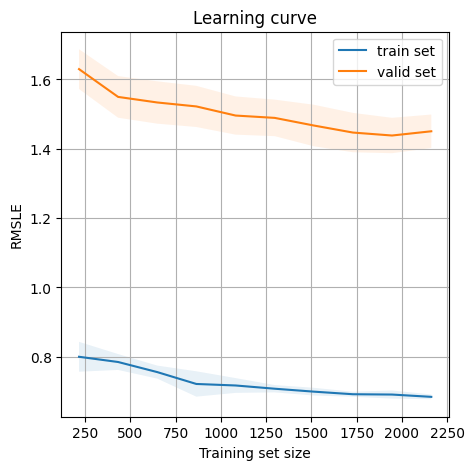

In [411]:
rf_param_grid = {
    'model__n_estimators': [50,100,200,300], 
    'model__max_depth': [12,15,18,20,30,38,45],         
    'model__min_samples_leaf': [1,2,3,4],           
}
cv_folds_rf = KFold(n_splits=3, shuffle=True, random_state=rnd_state)
rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=cv_folds_rf, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
rf_grid.fit(x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined)
rf_final_model = rf_grid.best_estimator_

print("Best hyperparameters:", rf_grid.best_params_)
print("RMSLE:", -rf_grid.best_score_)
plot_learning_curve(rf_final_model,x_combined.drop(["movie_title", "movie_imdb_link"],axis=1), y_combined)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best hyperparameters: {'model__max_depth': 14, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}
RMSLE: 1.4564290083401434


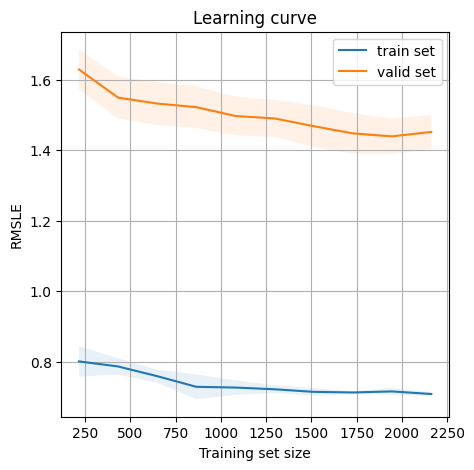

In [383]:
rf_param_grid_of = {
    'model__n_estimators': [200], 
    'model__max_depth': [14],         
    'model__min_samples_leaf': [2],           
}
rf_grid_of = GridSearchCV(rf_pipeline, rf_param_grid_of, cv=cv_folds_rf, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
rf_grid_of.fit(x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined)
rf_final_model_of = rf_grid_of.best_estimator_

print("Best hyperparameters:", rf_grid_of.best_params_)
print("RMSLE:", -rf_grid_of.best_score_)
plot_learning_curve(rf_final_model_of,x_combined.drop(["movie_title", "movie_imdb_link"],axis=1), y_combined)

In [ ]:
# conclusion

In [ ]:
root_mean_squared_error(y_test, rf_final_model.predict(x_test.drop(["movie_title", "movie_imdb_link"],axis=1))), root_mean_squared_error(y_test, rf_final_model_of.predict(x_test.drop(["movie_title", "movie_imdb_link"],axis=1)))
# 302,93%
# 303,46$ 

(1.3936065709729537, 1.3949379830789093)

In [61]:
rf_results = cross_validate(rf_final_model, x_combined.drop(["movie_title", "movie_imdb_link"],axis=1), y_combined, cv=cv_folds_rf, scoring = {'rmsle': 'neg_root_mean_squared_error', 'mae': mae_scorer, 'rmse': rmse_scorer})
rf_performance = {'rmsle': -rf_results['test_rmsle'].mean(), 'mae': -rf_results['test_mae'].mean(), 'rmse': -rf_results['test_rmse'].mean()}
rf_performance

{'rmsle': np.float64(1.4537765673948142),
 'mae': np.float64(23737718.01177436),
 'rmse': np.float64(43250595.52249464)}

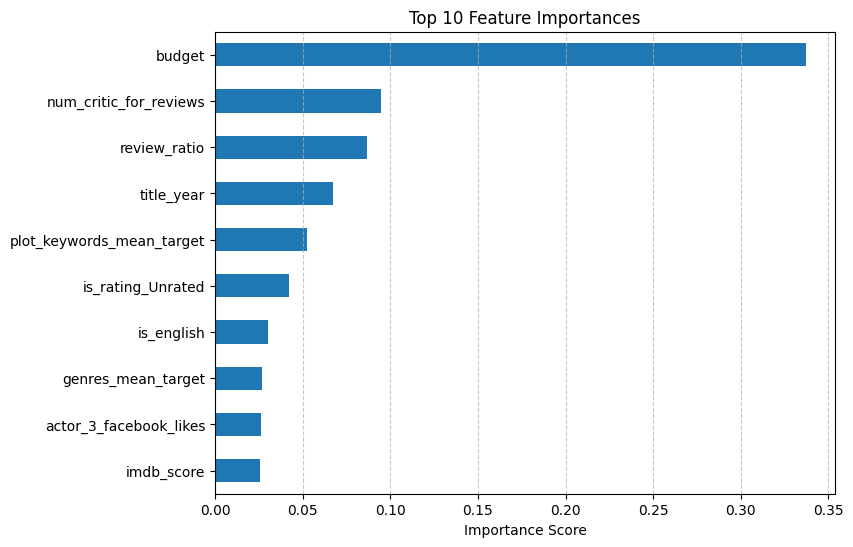

In [62]:
X_transformed = rf_final_model.named_steps['preprocessing'].transform(x_combined.drop(["movie_title", "movie_imdb_link"], axis=1))
feature_names = X_transformed.columns
importances = rf_final_model.named_steps['model'].feature_importances_
feature_importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
feature_importance_df.tail(10).plot(kind='barh')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#### 3.2.3 ElasticNet

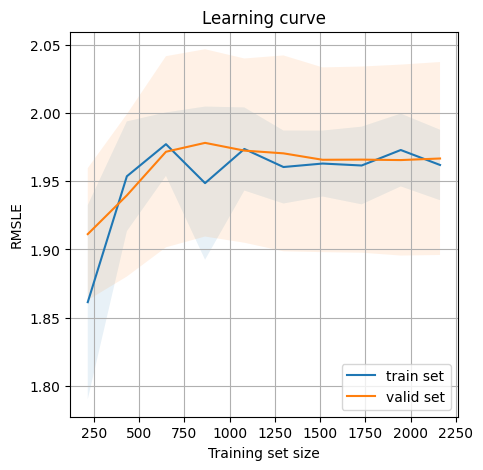

In [63]:
en = ElasticNet(random_state=rnd_state, max_iter = 10000)

log_transformer = FunctionTransformer(np.log1p, validate=True, feature_names_out="one-to-one")
column_log_transformer = ColumnTransformer(transformers=[('log', log_transformer, ['budget', "actor_1_facebook_likes", "actor_2_facebook_likes", "actor_3_facebook_likes",
                                           "movie_facebook_likes", "director_facebook_likes", "num_critic_for_reviews", "facenumber_in_poster", "war_symb_title"])], remainder="passthrough", verbose_feature_names_out=False)

scaler = ColumnTransformer(transformers=[('scaler', StandardScaler(), ["budget", "actor_1_facebook_likes", "actor_2_facebook_likes", "actor_3_facebook_likes", "movie_facebook_likes", "director_facebook_likes", "num_critic_for_reviews", "facenumber_in_poster",
                           "war_symb_title", "duration", "title_year", "imdb_score", "point_symb_title", "genres_mean_target", "plot_keywords_mean_target", "actor_counts", "director_counts", "review_ratio"])], remainder="passthrough", verbose_feature_names_out=False)

en_pipeline = Pipeline([('preprocessing', PrepareData()),('imputer', SimpleImputer(strategy='median')), ('log_trainsormer', column_log_transformer),('scaler', scaler), ('model', en)])
plot_learning_curve(en_pipeline, x_combined.drop(["movie_title", "movie_imdb_link"],axis=1), y_combined)

In [64]:
SCALERS = {
    'StandardScaler': StandardScaler(),
    'RobustScaler': RobustScaler(),
    'MinMaxScaler': MinMaxScaler()
}

def objective_en(trial):

    scaler_name = trial.suggest_categorical('scaler__scaler', ['StandardScaler', 'RobustScaler', 'MinMaxScaler'])
    
    param_space = {
        "model__alpha": trial.suggest_float('model__alpha', 0.0001, 5, log=True),
        "model__l1_ratio": trial.suggest_float('model__l1_ratio', 0.0001,1),
        "model__selection": trial.suggest_categorical('model__selection', ["random", "cyclic"]),
        "imputer__strategy": trial.suggest_categorical('imputer__strategy', ["mean", "median", "constant"]),
        "imputer__add_indicator": trial.suggest_categorical('imputer__add_indicator', [False, True]),
        "scaler__scaler": SCALERS[scaler_name]
    }

    en_pipeline.set_params(**param_space)
    scores = cross_val_score(en_pipeline, x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined, cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1)
    
    return -scores.mean()

sampler_en = TPESampler(seed=rnd_state)
study_en = optuna.create_study(direction='minimize', sampler=sampler_en)
study_en.optimize(objective_en, n_trials=500)
en_pipeline.set_params(**study_en.best_params)

best_params = study_en.best_params.copy()
best_params['scaler__scaler'] = SCALERS[best_params['scaler__scaler']]
en_pipeline.set_params(**best_params)

print("RMSE", study_en.best_value)
print("Best parameters", study_en.best_params)

RMSE 1.5197322428323978
Best parameters {'scaler__scaler': 'MinMaxScaler', 'model__alpha': 0.0037555391336528913, 'model__l1_ratio': 0.9996133909546767, 'model__selection': 'cyclic', 'imputer__strategy': 'mean', 'imputer__add_indicator': True}


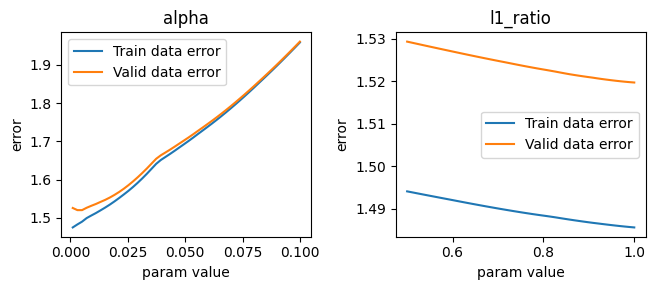

In [65]:
param_space_en = {
    'model__alpha': np.linspace(0.001,0.1,50),
    'model__l1_ratio': np.linspace(0.5,1,50),
}

plot_validation_curve(en_pipeline, x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined, param_space_en)

Fitting 3 folds for each of 900 candidates, totalling 2700 fits
Best params:  {'model__alpha': np.float64(0.001), 'model__l1_ratio': np.float64(0.8)}
RMSE:  1.5301423862871937


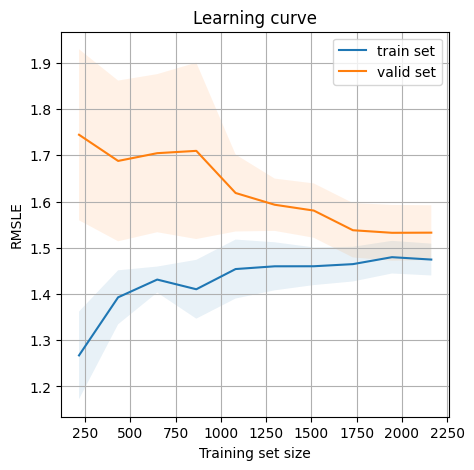

In [388]:
en_param_grid = {
    'model__l1_ratio': np.linspace(0.8,0.9999,30),
    'model__alpha': np.linspace(0.001, 0.01,30)
}
cv_folds_en = KFold(n_splits=3, shuffle = True, random_state=rnd_state)
en_grid = GridSearchCV(en_pipeline, cv=cv_folds_en, param_grid=en_param_grid, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
en_grid.fit(x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined)
en_final_model = en_grid.best_estimator_

print("Best params: ", en_grid.best_params_)
print("RMSE: ", -en_grid.best_score_)
plot_learning_curve(en_final_model, x_combined.drop(["movie_title", "movie_imdb_link"],axis=1), y_combined)

In [67]:
en_results = cross_validate(en_final_model, x_combined.drop(["movie_title", "movie_imdb_link"],axis=1), y_combined, cv=cv_folds_en, scoring = {'rmsle': 'neg_root_mean_squared_error', 'mae': mae_scorer, 'rmse': rmse_scorer})
en_performance = {'rmsle': -en_results['test_rmsle'].mean(), 'mae': -en_results['test_mae'].mean(), 'rmse': -en_results['test_rmse'].mean()}
en_performance

{'rmsle': np.float64(1.521322903744742),
 'mae': np.float64(26706596.737215668),
 'rmse': np.float64(48092009.53108051)}

In [68]:
coefs = en_final_model['model'].coef_
features = en_final_model['scaler'].get_feature_names_out()
pd.DataFrame({'Feature': features, 'coef': coefs}).sort_values(by='coef')

,Feature,coef
10,title_year,-4.1057
26,is_rating_Unrated,-1.1003
18,is_missing_budget,-1.0812
17,review_ratio,-0.7515
4,movie_facebook_likes,-0.0823
7,facenumber_in_poster,-0.0700
1,actor_1_facebook_likes,-0.0271
34,missingindicator_facenumber_in_poster,0.0000
33,missingindicator_actor_1_facebook_likes,0.0000
32,missingindicator_actor_3_facebook_likes,-0.0000


#### 3.2.4 SVR

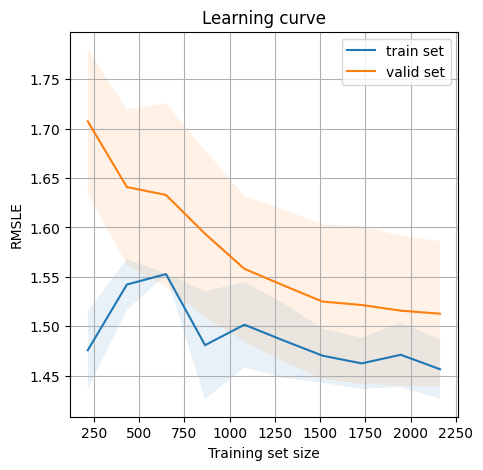

In [69]:
svr = SVR(max_iter=50000)
svr_pipeline = Pipeline([('preprocessing', PrepareData()), ('imputer', SimpleImputer(strategy='median')), ('log_transformer', column_log_transformer), ('scaler', scaler), ('model', svr)])
plot_learning_curve(svr_pipeline, x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined)

In [70]:
def objective_svr(trial):
    scaler_name = trial.suggest_categorical('scaler__scaler', ['StandardScaler', 'RobustScaler', 'MinMaxScaler'])
    param_space = {
        'model__C': trial.suggest_float('model__C',0.01,8, log=True),
        'model__gamma': trial.suggest_categorical('model__gamma', ['scale', 'auto', 0.2, 0.1, 0.01, 0.001, 0.0001]),
        'model__epsilon': trial.suggest_float('model__epsilon', 0.1, 1, log=True),
        'model__kernel': trial.suggest_categorical('model__kernel', ['sigmoid', 'rbf']),
        'imputer__strategy': trial.suggest_categorical('imputer__strategy', ['median', 'mean', 'constant']),
        'imputer__add_indicator': trial.suggest_categorical('imputer__add_indicator', [True, False]),
        'scaler__scaler': SCALERS[scaler_name]
    }

    svr_pipeline.set_params(**param_space)
    score = cross_val_score(svr_pipeline, x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined, cv=3, n_jobs=-1, scoring='neg_root_mean_squared_error')
    return -score.mean()

sampler_svr = TPESampler(seed=rnd_state)
study_svr = optuna.create_study(direction="minimize", sampler=sampler_svr)
study_svr.optimize(objective_svr,n_trials=200)

best_params_svr = study_svr.best_params.copy()
best_params_svr['scaler__scaler'] = SCALERS[best_params_svr['scaler__scaler']]
svr_pipeline.set_params(**best_params_svr)

print("RMSE: ", study_svr.best_value)
print("Best params:", study_svr.best_params)

RMSE:  1.4278331758331706
Best params: {'scaler__scaler': 'StandardScaler', 'model__C': 5.795934400063314, 'model__gamma': 'auto', 'model__epsilon': 0.5528293060302205, 'model__kernel': 'rbf', 'imputer__strategy': 'mean', 'imputer__add_indicator': True}


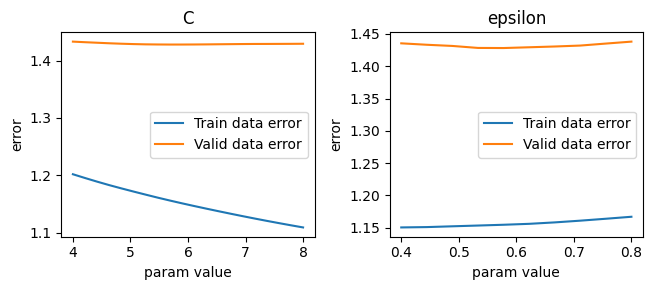

In [71]:
svr_params_vc = {
    'model__C': np.linspace(4,8,20),
    'model__epsilon': np.linspace(0.4, 0.8, 10),
}
plot_validation_curve(svr_pipeline, x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined,svr_params_vc)

Fitting 3 folds for each of 400 candidates, totalling 1200 fits
Best hyperparameters:  {'model__C': np.float64(8.0), 'model__epsilon': np.float64(0.6473684210526316)}
RMSLE:  1.4218785564714376


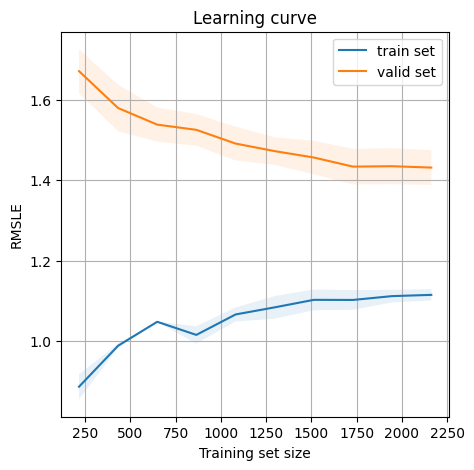

In [393]:
svr_param_grid = {
    'model__C': np.linspace(2.5, 8,20),
    'model__epsilon': np.linspace(0.45, 0.7,20)
}
cv_folds_svr = KFold(n_splits=3, random_state=rnd_state, shuffle=True)
svr_grid = GridSearchCV(svr_pipeline, svr_param_grid, cv=cv_folds_svr, n_jobs=-1, verbose=1, scoring='neg_root_mean_squared_error')
svr_grid.fit(x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined)
svr_final_model = svr_grid.best_estimator_

print("Best hyperparameters: ", svr_grid.best_params_)
print("RMSLE: ", -svr_grid.best_score_)
plot_learning_curve(svr_final_model, x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined)

In [396]:
svr_results = cross_validate(svr_final_model, x_combined.drop(["movie_title", "movie_imdb_link"],axis=1), y_combined, cv=cv_folds_svr, scoring = {'rmsle': 'neg_root_mean_squared_error', 'mae': mae_scorer, 'rmse': rmse_scorer})
svr_performance = {'rmsle': -svr_results['test_rmsle'].mean(), 'mae': -svr_results['test_mae'].mean(), 'rmse': -svr_results['test_rmse'].mean()}
svr_performance

{'rmsle': np.float64(1.4218785564714376),
 'mae': np.float64(24993612.757654026),
 'rmse': np.float64(46449782.66481206)}

#### 3.2.5 ExtraTrees

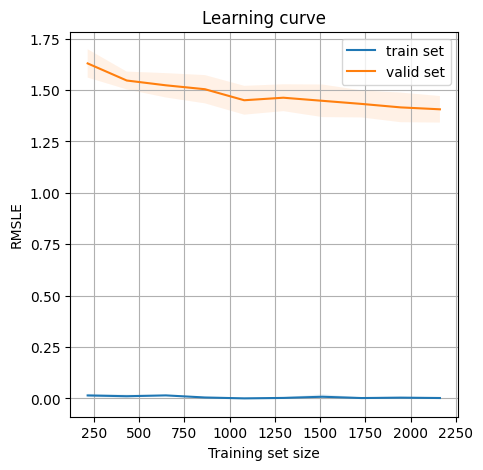

In [74]:
et = ExtraTreesRegressor(random_state=rnd_state)
et_pipeline = Pipeline([("preprocessing", PrepareData()), ("model", et)])
plot_learning_curve(et_pipeline, x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined)

In [75]:
def objective_et(trial):
    params_space = {
        'model__n_estimators': trial.suggest_int('model__n_estimators',100,800),
        'model__max_depth': trial.suggest_int('model__max_depth',2,50),
        'model__max_features': trial.suggest_categorical('model__max_features',[0.9,0.8,'sqrt','log2']),
        'model__min_samples_leaf': trial.suggest_int('model__min_samples_leaf',7,40)
    }
    et_pipeline.set_params(**params_space)
    score = cross_val_score(et_pipeline, x_combined.drop(["movie_title", "movie_imdb_link"], axis=1),y_combined, cv=3, n_jobs=-1, scoring='neg_root_mean_squared_error')
    return -score.mean()

et_sampler = TPESampler(seed=rnd_state)
study_et = optuna.create_study(direction="minimize", sampler=et_sampler)
study_et.optimize(objective_et, n_trials=80)
et_pipeline.set_params(**study_et.best_params)

print("RMSE:", study_et.best_value)
print("Best parameters", study_et.best_params)

RMSE: 1.4177549960098148
Best parameters {'model__n_estimators': 375, 'model__max_depth': 16, 'model__max_features': 0.9, 'model__min_samples_leaf': 7}


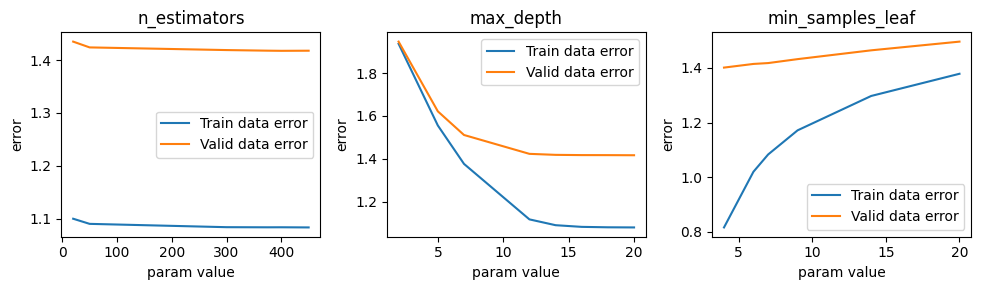

In [76]:
param_space_et = {
        'model__n_estimators': [20,50,300,375,400,450],
        'model__max_depth': [2,5,7,12,14,16,18,20],
        'model__min_samples_leaf': [4,6,7,9,14,20]
}

plot_validation_curve(et_pipeline, x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined, param_space_et)

Fitting 3 folds for each of 80 candidates, totalling 240 fits
Best hyperparameters:  {'model__max_depth': 18, 'model__min_samples_leaf': 2, 'model__n_estimators': 375}
RMSE:  1.403272704546934


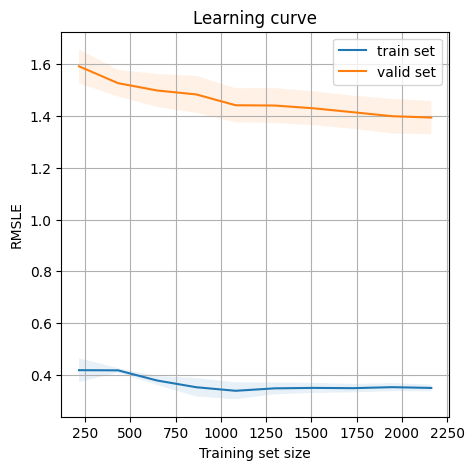

In [77]:
et_param_grid = {
        'model__n_estimators': [50,150,250,375],
        'model__max_depth': [12,14,16,18],
        'model__min_samples_leaf': [1,2,3,4,5]
}
cv_folds_et = KFold(n_splits=3, shuffle=True,random_state=rnd_state)
et_grid = GridSearchCV(et_pipeline, cv=cv_folds_et, param_grid=et_param_grid, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
et_grid.fit(x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined)
et_final_model = et_grid.best_estimator_

print("Best hyperparameters: ", et_grid.best_params_)
print("RMSE: ", -et_grid.best_score_)
plot_learning_curve(et_final_model, x_combined.drop(["movie_title", "movie_imdb_link"],axis=1), y_combined)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best hyperparameters:  {'model__max_depth': 13, 'model__min_samples_leaf': 2, 'model__n_estimators': 375}
RMSE:  1.41237238870965


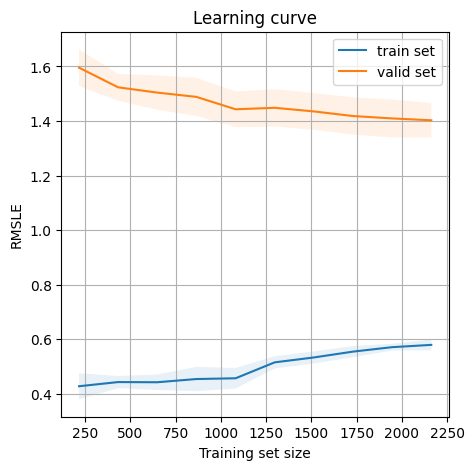

In [ ]:
# increasing max_depth doesn't change the plot
# decreasing max_depth cause that both train and validation error is higher
et_param_grid_of = {
        'model__n_estimators': [375],
        'model__max_depth': [11,12,13],
        'model__min_samples_leaf': [2]
}
et_grid_of = GridSearchCV(et_pipeline, cv=cv_folds_et, param_grid=et_param_grid_of, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
et_grid_of.fit(x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined)
et_final_model_of = et_grid_of.best_estimator_

print("Best hyperparameters: ", et_grid_of.best_params_)
print("RMSE: ", -et_grid_of.best_score_)
plot_learning_curve(et_final_model_of, x_combined.drop(["movie_title", "movie_imdb_link"],axis=1), y_combined)

In [78]:
et_results = cross_validate(et_final_model, x_combined.drop(["movie_title", "movie_imdb_link"],axis=1), y_combined, cv=cv_folds_et, scoring = {'rmsle': 'neg_root_mean_squared_error', 'mae': mae_scorer, 'rmse': rmse_scorer})
et_performance = {'rmsle': -et_results['test_rmsle'].mean(), 'mae': -et_results['test_mae'].mean(), 'rmse': -et_results['test_rmse'].mean()}
et_performance

{'rmsle': np.float64(1.403272704546934),
 'mae': np.float64(23841643.41199143),
 'rmse': np.float64(44086303.25715854)}

### 3.3 Results analysis

In [397]:
# mean results from crossvalidation on train+valid set
results = {'histGradientBoosting': gb_performance, 'randomForest': rf_performance, 'elasticNet': en_performance, 'svr': svr_performance, 'ExtraTree': et_performance}
results = pd.DataFrame(results)
results

,histGradientBoosting,randomForest,elasticNet,svr,ExtraTree
rmsle,1.3886,1.4538,1.5213,1.4219,1.4033
mae,23507298.9338,23737718.0118,26706596.7372,24993612.7577,23841643.4120
rmse,43010330.0091,43250595.5225,48092009.5311,46449782.6648,44086303.2572


In [398]:
test_results = {
    'Baseline': evaluate_model(y_test, baseline_pipeline.predict(x_test.drop(["movie_title", "movie_imdb_link"], axis=1))),
    'histGradientBossting': evaluate_model(y_test, gb_final_model.predict(x_test.drop(["movie_title", "movie_imdb_link"], axis=1))),
    'RandomForest': evaluate_model(y_test, rf_final_model.predict(x_test.drop(["movie_title", "movie_imdb_link"], axis=1))),
    'ElasticNet': evaluate_model(y_test, en_final_model.predict(x_test.drop(["movie_title", "movie_imdb_link"], axis=1))),
    'SVR': evaluate_model(y_test, svr_final_model.predict(x_test.drop(["movie_title", "movie_imdb_link"], axis=1))),
    'ExtraTrees': evaluate_model(y_test, et_final_model.predict(x_test.drop(["movie_title", "movie_imdb_link"], axis=1))),
    }
test_results = pd.DataFrame(test_results)
test_results

RMSLE = 1.6018
MAE = 34437278.2214
rmse = 88224800.4163
RMSLE = 1.3158
MAE = 22418734.9111
rmse = 46490081.9596
RMSLE = 1.3936
MAE = 23244387.0549
rmse = 48010950.0319
RMSLE = 1.4885
MAE = 26410832.2599
rmse = 51770933.5891
RMSLE = 1.376
MAE = 23529673.774
rmse = 47438274.2503
RMSLE = 1.3478
MAE = 22987437.2098
rmse = 47317071.5376


,Baseline,histGradientBossting,RandomForest,ElasticNet,SVR,ExtraTrees
rmsle,1.6018,1.3158,1.3936,1.4885,1.3760,1.3478
mae,34437278.2214,22418734.9111,23244387.0549,26410832.2599,23529673.7740,22987437.2098
rmse,88224800.4163,46490081.9596,48010950.0319,51770933.5891,47438274.2503,47317071.5376


#### 3.3.1 Statistical significance analysis - between models

In [399]:
# spliting test data into 15 parts
parts_x = np.array_split(x_test, 15)
parts_y = np.array_split(y_test,15)

gb_results = []
rf_results = []
en_results = []
et_results = []
svr_results = []

for i in range(len(parts_x)):
    x_test_i = pd.DataFrame(parts_x[i])
    x_test_i.columns = x_valid.columns

    preds_gb = gb_final_model.predict(x_test_i.drop(["movie_title", "movie_imdb_link"], axis=1))
    gb_results.append(root_mean_squared_error(parts_y[i], preds_gb))
    preds_rf = rf_final_model.predict(x_test_i.drop(["movie_title", "movie_imdb_link"], axis=1))
    rf_results.append(root_mean_squared_error(parts_y[i], preds_rf))
    preds_en = en_final_model.predict(x_test_i.drop(["movie_title", "movie_imdb_link"], axis=1))
    en_results.append(root_mean_squared_error(parts_y[i], preds_en))
    preds_et = et_final_model.predict(x_test_i.drop(["movie_title", "movie_imdb_link"], axis=1))
    et_results.append(root_mean_squared_error(parts_y[i], preds_et))
    preds_svr = svr_final_model.predict(x_test_i.drop(["movie_title", "movie_imdb_link"], axis=1))
    svr_results.append(root_mean_squared_error(parts_y[i], preds_svr))


In [400]:
print(np.mean(gb_results), np.mean(rf_results), np.mean(en_results), np.mean(et_results), np.mean(svr_results))

1.300449609194176 1.3791196941566646 1.476561012777539 1.3332172986830853 1.3591946758209947


In [401]:
# Friedman's test
# H0: There is no significant difference between the performances of the models
# H1: There is significant difference between the performances of the models

stat, p_value = stats.friedmanchisquare(gb_results, rf_results, en_results, et_results, svr_results)
print(f"p_value: {p_value:.4f}")
# We reject the null hypothesis. There is significant difference between model

p_value: 0.0001


In [402]:
# H0: There is no siginificant difference between model 1 and model 2
# H1: There is siginificant difference between model 1 and model 2

res = pd.DataFrame({
    'gradientboosting': gb_results, 
    'extratrees': et_results, 
    'svr': svr_results,
    'randomforest': rf_results,
    'elasticnet': en_results
})

posthoc_results = sp.posthoc_nemenyi_friedman(res)
posthoc_results
# Gradientboosting is significantlt different from elastic net and svr. There is no significant different between gradient boosting, extra trees and RandomForest.

,gradientboosting,extratrees,svr,randomforest,elasticnet
gradientboosting,1.0000,0.6369,0.2843,0.1087,0.0000
extratrees,0.6369,1.0000,0.9784,0.8371,0.0107
svr,0.2843,0.9784,1.0000,0.9907,0.0607
randomforest,0.1087,0.8371,0.9907,1.0000,0.1819
elasticnet,0.0000,0.0107,0.0607,0.1819,1.0000


In [ ]:
# Summary:
# The Friedman test confirmed siginificant differences in performance across the evaluated models.
# However, post-hoc tests reveal no significant difference between histGradientboosting, extraTrees, svr and random forest at the 0.05 significant level.
# Based on the test set performance and these analysis these 4 models can be cosidered the top-performing models in this task.
# taking into account the best results on the test set and tests' results, I have selected histGradientBoosting as the final model

#### 3.3.2 Statistical significance analysis - random seeds

In [86]:
random_states = [3, 543, 423, 2132, 213132, 422222, 212, 931]
scores = []
gb_test_model = clone(gb_final_model)
for state in random_states:
    state_scores = []
    gb_test_model.set_params(model__random_state=state)
    gb_test_model.fit(x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined)
    for i in range(len(parts_x)):
        x_test_i = pd.DataFrame(parts_x[i])
        x_test_i.columns = x_valid.columns
        preds = gb_test_model.predict(x_test_i.drop(["movie_title", "movie_imdb_link"], axis=1))
        state_scores.append(root_mean_squared_error(parts_y[i], preds))
    scores.append(state_scores)
scores

[[1.0137344949067792,
  1.0330617978068763,
  0.9788814023405743,
  1.3609014440882736,
  1.158318598015795,
  1.3141196433732947,
  1.2366390098913838,
  1.2647964094916124,
  1.31381139056595,
  1.4869609241702881,
  1.172311823886038,
  1.357291675000604,
  1.547697559117562,
  1.5034332697773924,
  1.5162398086786648],
 [1.1367159083011549,
  1.0290014266062524,
  0.9403603693865303,
  1.3559274591368446,
  1.1657583879525353,
  1.364423063680907,
  1.1636658685395562,
  1.3559445618702148,
  1.3336210571302212,
  1.5292956740452943,
  1.231483896798763,
  1.3936012176607897,
  1.5106849330118397,
  1.4206592096277653,
  1.5288305942597975],
 [1.0883061501370332,
  0.9899334127321713,
  1.0280375774917196,
  1.4051610519478834,
  1.1684173435269904,
  1.2868797782858201,
  1.2921560427192098,
  1.2584463854676289,
  1.345628795153471,
  1.5860195016713785,
  1.2608973214000805,
  1.3740822225022213,
  1.5679239251801032,
  1.5379115924479154,
  1.5568809640117416],
 [1.098261107436

In [87]:
# H0: There is no significant difference between model performance for different seeds
# H1: There is significant difference betwwen model performance for different seeds
stat_val , p_val = stats.friedmanchisquare(scores[0], scores[1], scores[2], scores[3], scores[4])
p_val
# We fail to reject the null hypothesis

np.float64(0.18563485140664895)

#### 3.1.2 Errors analysis

In [88]:
results_df = x_test.copy()
gb_pred = gb_final_model.predict(x_test.drop(["movie_title", "movie_imdb_link"],axis=1))
results_df["gross_mln"] = np.exp(y_test) / 1000000
results_df["gross_prediction_mln"] = np.exp(gb_pred) / 1000000
results_df["budget_mln"] = results_df["budget"] / 1000000
results_df["abs(error_mln)"] = abs(results_df["gross_mln"] - results_df["gross_prediction_mln"])
results_df["abs(rel_error)"] = abs(results_df["gross_mln"] - results_df["gross_prediction_mln"]) / abs(results_df["gross_mln"])
pred_check = results_df[["movie_title", "director_name", "actor_1_name", "budget_mln", "imdb_score", "gross_mln", "gross_prediction_mln", "abs(error_mln)", "abs(rel_error)"]]
print("relative error > 5:", len(pred_check[pred_check["abs(rel_error)"] > 5 ]), "\n(relative error > 5) & (gross < 1 mln): ", len(pred_check[(pred_check["abs(rel_error)"] > 5) & (pred_check.gross_mln < 1)]))
print("relative error < 1: ", len(pred_check[pred_check["abs(rel_error)"] < 1 ]), "\n(relative error < 1) & (gross < 1 mln): ", len(pred_check[(pred_check["abs(rel_error)"] < 1) & (pred_check.gross_mln < 1)]))
pred_check.sort_values(by="abs(rel_error)", ascending=False).head(15)
# extremly erros are mainly linked to low gross value

relative error > 5: 61 
(relative error > 5) & (gross < 1 mln):  52
relative error < 1:  648 
(relative error < 1) & (gross < 1 mln):  42


,movie_title,director_name,actor_1_name,budget_mln,imdb_score,gross_mln,gross_prediction_mln,abs(error_mln),abs(rel_error)
3631,The Butterfly Effect,Eric Bress,Logan Lerman,13.0000,7.7000,0.0239,28.0213,27.9974,1169.1388
2741,Plush,Catherine Hardwicke,Frances Fisher,NaN,5.4000,0.0028,0.9184,0.9156,322.0417
308,Anatomy,Stefan Ruzowitzky,Benno Fürmann,8.4000,6.1000,0.0057,1.1733,1.1676,203.9413
2238,Maggie,Henry Hobson,Joely Richardson,8.5000,5.6000,0.1312,26.5332,26.4020,201.2731
2304,Mean Streets,Martin Scorsese,Robert De Niro,0.5000,7.4000,0.0326,6.2863,6.2536,191.5650
3097,Shade,Damian Nieman,Glenn Plummer,6.8000,6.4000,0.0107,1.8795,1.8689,174.7242
4198,The Polar Express,Robert Zemeckis,Tom Hanks,165.0000,6.6000,0.6654,100.9991,100.3336,150.7810
4387,The Trials of Darryl Hunt,Ricki Stern,Darryl Hunt,0.2000,7.7000,0.0011,0.1665,0.1654,148.8923
3477,Teeth,Mitchell Lichtenstein,Jess Weixler,NaN,5.4000,0.3476,29.9622,29.6146,85.2029
264,Amen.,Costa-Gavras,Sebastian Koch,103.0000,7.3000,0.2743,21.9568,21.6825,79.0469


In [89]:
# The Butterfly Effect: Actual gross is $96M, table reflects a limited re-release 
# Anatomy: Actual gross is $10M, table only tracks US domestic revenue

In [90]:
pred_check.budget_mln.mean()

np.float64(37.06016806625286)

In [91]:
print("relative error > 5:", len(pred_check[pred_check["abs(rel_error)"] > 5 ]), "\n(relative error > 5) & (budget < 15 mln): ", len(pred_check[(pred_check["abs(rel_error)"] > 5) & (pred_check.budget_mln < 15)]))
print("(relative error > 5) & (budget/gross > 5): ", len(pred_check[(pred_check["abs(rel_error)"] > 5) & (pred_check.budget_mln/pred_check.gross_mln  > 5)]))
pred_check[(pred_check["abs(rel_error)"] > 5) & (pred_check.budget_mln/pred_check.gross_mln  > 4)].head(20)
# extremly errors mainly occurs when budget is much higher then gross 

relative error > 5: 61 
(relative error > 5) & (budget < 15 mln):  37
(relative error > 5) & (budget/gross > 5):  42


,movie_title,director_name,actor_1_name,budget_mln,imdb_score,gross_mln,gross_prediction_mln,abs(error_mln),abs(rel_error)
3272,Special,Hal Haberman,Michael Rapaport,1.0000,6.9000,0.0064,0.2375,0.2311,36.1790
2850,Rapa Nui,Kevin Reynolds,Esai Morales,20.0000,6.4000,0.3051,5.3444,5.0393,16.5186
3732,The Divide,Xavier Gens,Michael Biehn,3.0000,5.8000,0.0220,1.2006,1.1786,53.5718
4830,Without Limits,Robert Towne,Billy Burke,25.0000,7.2000,0.7774,7.5194,6.7420,8.6722
3918,The Iceman,Ariel Vromen,Chris Evans,10.0000,6.9000,1.9394,14.1280,12.1885,6.2846
411,Bachelorette,Leslye Headland,Kirsten Dunst,3.0000,5.3000,0.4183,4.0496,3.6314,8.6819
1073,Donkey Punch,Oliver Blackburn,Julian Morris,0.9000,5.2000,0.0184,0.1704,0.1520,8.2731
1646,Heaven's Gate,Michael Cimino,Jeff Bridges,44.0000,6.8000,1.5000,15.5208,14.0208,9.3472
252,Alone with Her,Eric Nicholas,Jordana Spiro,1.0000,6.1000,0.0100,0.1300,0.1200,11.9775
1879,Interview with the Assassin,Neil Burger,Raymond J. Barry,0.7500,6.6000,0.0473,0.3348,0.2875,6.0746


In [92]:
print("budget/gross_predicted > 5: ",len(results_df[results_df["budget_mln"] / results_df.gross_prediction_mln > 5 ]))
print("budget/gross_predicted > 5 & gross_predicted > gross_true",len(results_df[(results_df["budget_mln"] / results_df.gross_prediction_mln > 5 ) & (results_df.gross_mln < results_df.gross_prediction_mln)]))

budget/gross_predicted > 5:  72
budget/gross_predicted > 5 & gross_predicted > gross_true 28


In [93]:
print("Statistics for data where budget/gross_predicted > 5: \n")
print("mean(gross_mln): ",results_df.loc[results_df["budget_mln"] / results_df.gross_prediction_mln > 5 , 'gross_mln'].mean())
print("mean(gross_predicted_mln): ",results_df.loc[results_df["budget_mln"] / results_df.gross_prediction_mln > 5 , 'gross_prediction_mln'].mean())
print("median(gross_mln): ",results_df.loc[results_df["budget_mln"] / results_df.gross_prediction_mln > 5 , 'gross_mln'].median())
print("median(gross_predicted_mln): ",results_df.loc[results_df["budget_mln"] / results_df.gross_prediction_mln > 5 , 'gross_prediction_mln'].median())

Statistics for data where budget/gross_predicted > 5: 

mean(gross_mln):  2.398880583333334
mean(gross_predicted_mln):  1.2141735507936409
median(gross_mln):  0.3991065000000001
median(gross_predicted_mln):  0.32748305368750896


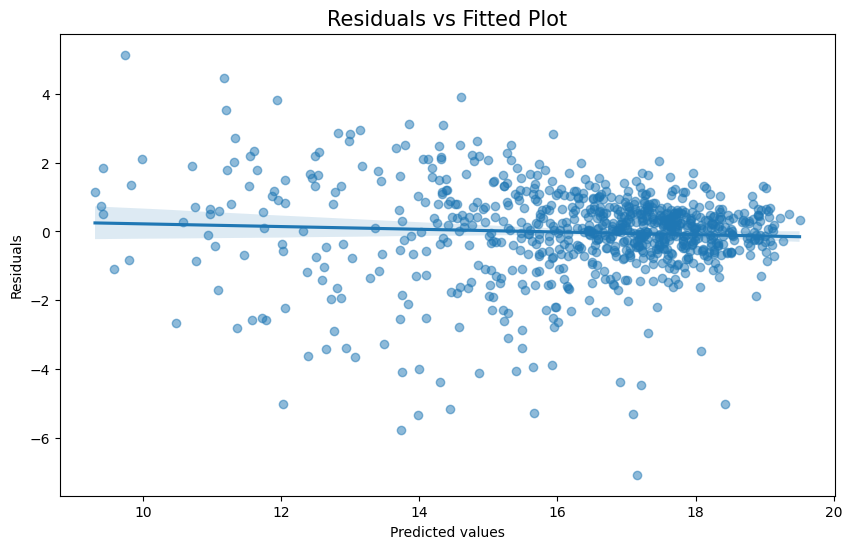

In [94]:
def plot_residuals_vs_fitted(y_true, y_pred, title="Residuals vs Fitted Plot"):
    residuals = y_true - y_pred
    plt.figure(figsize=(10, 6))
    sns.regplot(x=y_pred, y=residuals, 
                scatter_kws={'alpha': 0.5})
        
    plt.title(title, fontsize=15)
    plt.xlabel("Predicted values")
    plt.ylabel("Residuals")
    plt.show()

plot_residuals_vs_fitted(y_test, gb_pred)

2.8029647822892327e-19


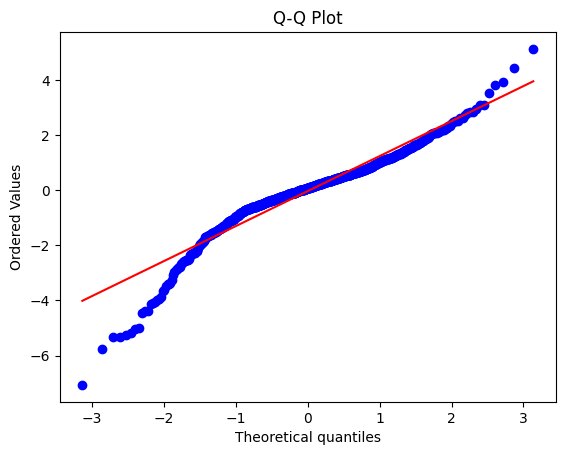

In [95]:
residuals = y_test - gb_pred
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
shapiro_test = stats.shapiro(residuals)
print(shapiro_test.pvalue)
plt.show()

# heavy tails: the downward curve highlights major negative residuals caused by the model over-predicting 

#### Key Performance conclusions
- Absolute Error: Our average margin of error is 22.4 million. For large-scale productions, this is a useful benchmark, but for small-budget films, this error might be significant.

- Relative Error: The high percentage error (273%) suggests that the model is better at telling us if a movie will be "Big" or "Small" (the scale) rather than predicting the exact dollar amount.

So the model provides a general scale rather than a precise figure.

### Errors conclusions and potencial next steps:
#### Conclusion
- The model tends to significantly overestimate the gross value for certain movies. These are typically movie flop where the budget greatly exceeds the actual gross, often occuring within the low-budget segment.
- The model appers to be more confident  when predicting higher values (lower variance in residauls).
- In many cases, high model errors were caused by the data rather tham the model itself. This was due to data inconsistencies, where e.g. the gorss revenue for certain movies was based only on the opeening weekend or mistakenly taken form a different movie with the same title.
#### Recommended next steps:
- Create a new feature to help the model better identify low-budget movies (for example is_budget_lower_then_10_mln)
- Apply sample weight to high-error cases or collect more data representing fanancial failures.

## 4. Classification task - predit if imdb_score >= 7.5

In [51]:
rnd_state = 123

X = df[~df.imdb_score.isna()]
y = (df.loc[~df.imdb_score.isna(), "imdb_score"] >= 7.5).astype(int)
x_temp, x_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=rnd_state)
x_train, x_valid, y_train, y_valid = train_test_split(x_temp, y_temp, test_size=0.25, random_state=rnd_state)
x_combined = pd.concat([x_train, x_valid])
y_combined = pd.concat([y_train, y_valid])

In [52]:
print("y_all: ",round(len(y[y==1]) / len(y),2), "y_combined: ", round(len(y_combined[y_combined==1]) / len(y_combined),2), "y_test: ", round(len(y_test[y_test==1]) / len(y_test),2))
# the data is unbalanced

y_all:  0.17 y_combined:  0.17 y_test:  0.19


### 4.1 Modeling

#### 4.1.1 Baseline model

F1_score:  0.261 
Precision_score:  0.667 
Balanced_accuracy:  0.572


/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:

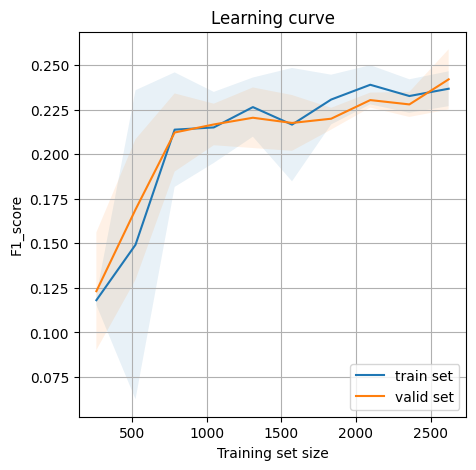

In [53]:
baseline = Pipeline([('preprocessing', PrepareData(regression_task=False)), ('imputer', SimpleImputer()), ('model', LogisticRegression(max_iter=1000))])
baseline.fit(x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined)
baseline_performance = evaluate_model(y_test ,baseline.predict(x_test.drop(["movie_title", "movie_imdb_link"], axis=1)), regression_task=False)
plot_learning_curve(baseline, x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined, regression_task=False)

#### 4.1.2 XGBoost

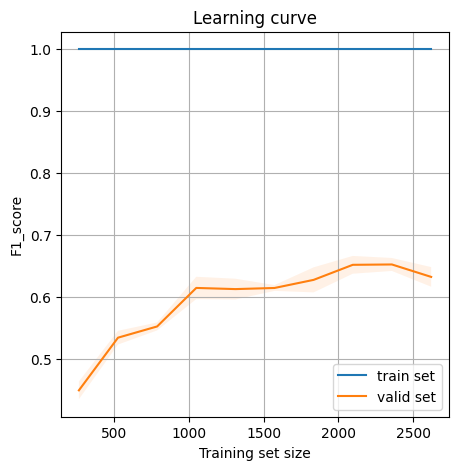

In [54]:
xgb_pipeline = Pipeline([('preprocessing', PrepareData(regression_task=False)), ('model', XGBClassifier(random_state=rnd_state))])
plot_learning_curve(xgb_pipeline, x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined, regression_task=False)

In [55]:
def objective_xgb(trial):
    param_space = {
        'model__max_depth': trial.suggest_int('model__max_depth', 2, 15),
        'model__learning_rate': trial.suggest_float('model__learning_rate', 0.01, 0.2, log=True),
        'model__n_estimators': trial.suggest_int('model__n_estimators', 20, 500),
        'model__gamma': trial.suggest_float('model__gamma', 0.01, 5.0, log=True), # minimum gain required for splitting
        'model__min_child_weight': trial.suggest_int('model__min_child_weight', 3, 12),
        'model__lambda': trial.suggest_float('model__lambda', 0.1, 10.0, log=True),   #l2
        'model__alpha': trial.suggest_float('model__alpha', 0.1, 10.0, log=True),  #l1
        'model__subsample': trial.suggest_categorical('model__subsample', [0.7,0.8,0.9])} 
    xgb_pipeline.set_params(**param_space)
    score = cross_val_score(xgb_pipeline, x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined, cv=3, n_jobs=-1, scoring='f1')
    return score.mean()

In [56]:
xgb_sampler = TPESampler(seed=rnd_state)
study_xgb = optuna.create_study(direction="maximize", sampler=xgb_sampler)
study_xgb.optimize(objective_xgb, n_trials=100)
xgb_pipeline.set_params(**study_xgb.best_params)

print("Best hyperparameters: ", study_xgb.best_params)
print("F1_score = ",study_xgb.best_value)

Best hyperparameters:  {'model__max_depth': 6, 'model__learning_rate': 0.041330435349186984, 'model__n_estimators': 377, 'model__gamma': 0.1190728637771989, 'model__min_child_weight': 9, 'model__lambda': 1.2992938312969302, 'model__alpha': 0.28904242102538974, 'model__subsample': 0.9}
F1_score =  0.6823292620230198


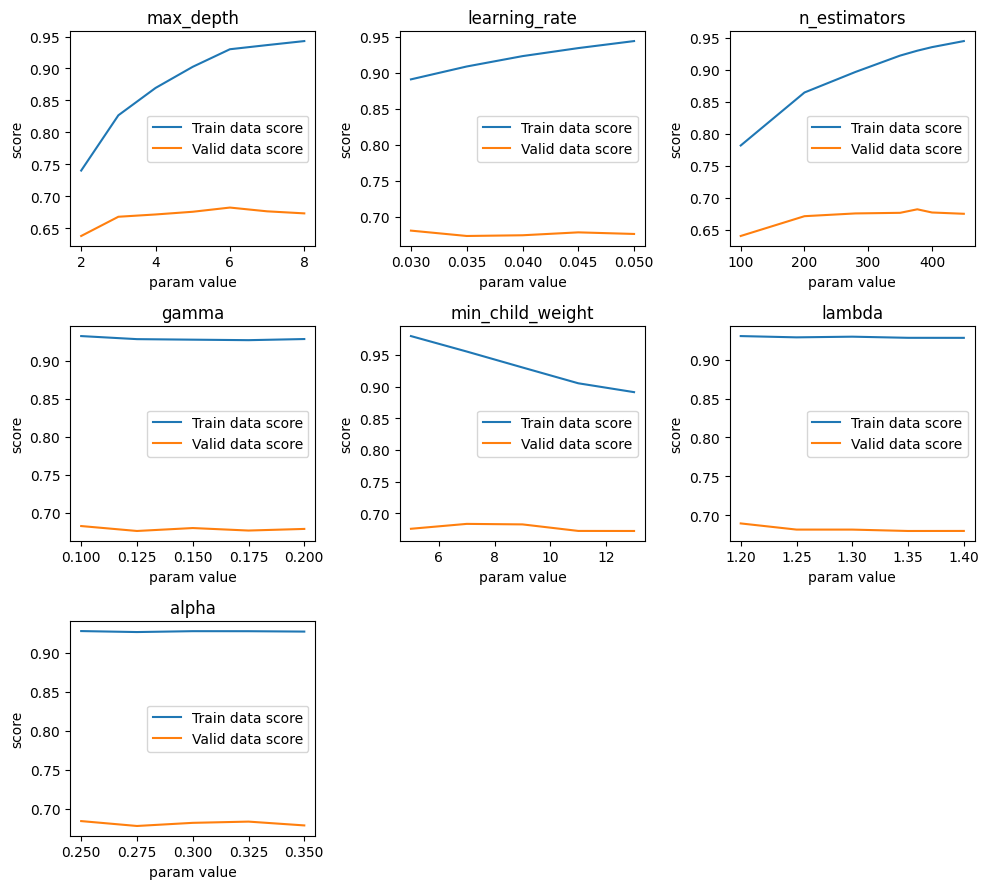

In [57]:
xgb_param_space = {
    'model__max_depth': [2,3,4,5,6,7,8],
    'model__learning_rate': np.linspace(0.03,0.05,5),
    'model__n_estimators': [100,200,280,350,377,400,450],
    'model__gamma': np.linspace(0.1, 0.2,5),
    'model__min_child_weight': [5,7,9,11,13],
    'model__lambda': np.linspace(1.2,1.4,5),
    'model__alpha': np.linspace(0.25,0.35,5)
}

plot_validation_curve(xgb_pipeline, x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined, regression_task=False, params=xgb_param_space)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best hyperparameters:  {'model__max_depth': 8, 'model__min_child_weight': 8, 'model__n_estimators': 350}
F1 =  0.667688316764834


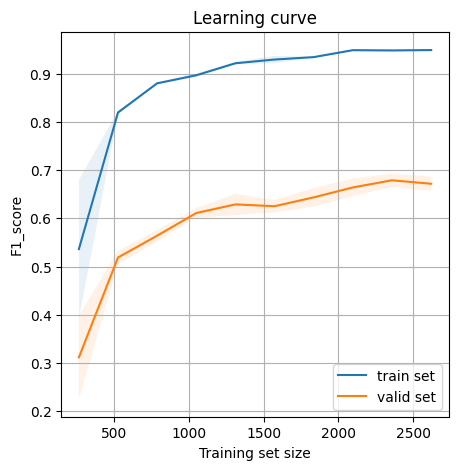

In [58]:
xgb_param_space = {
    'model__max_depth': [6,7,8],
    'model__n_estimators': [250,350,377,390],
    'model__min_child_weight': [7,8,9]
}

cv_folds_xgb = KFold(n_splits=3, shuffle=True, random_state=rnd_state)
xgb_grid = GridSearchCV(xgb_pipeline, cv =cv_folds_xgb, param_grid=xgb_param_space, scoring='f1', n_jobs=-1, verbose=1)
xgb_grid.fit(x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined)
xgb_final_model = xgb_grid.best_estimator_

print("Best hyperparameters: ", xgb_grid.best_params_)
print("F1 = ", xgb_grid.best_score_)
plot_learning_curve(xgb_final_model, x_combined.drop(["movie_title", "movie_imdb_link"],axis=1), y_combined, regression_task=False)

In [59]:
xgb_results = cross_validate(xgb_final_model, x_combined.drop(["movie_title", "movie_imdb_link"],axis=1), y_combined, cv=cv_folds_xgb, scoring = {'f1': 'f1', 'precision': 'precision', 'balanced_accuracy': 'balanced_accuracy'})
xgb_performance = {'f1': xgb_results['test_f1'].mean(), 'precision': xgb_results['test_precision'].mean(), 'balanced_accuracy': xgb_results['test_balanced_accuracy'].mean()}
xgb_performance

{'f1': np.float64(0.667688316764834),
 'precision': np.float64(0.7788872869610035),
 'balanced_accuracy': np.float64(0.7750330980367837)}

#### 4..13 LightGBM

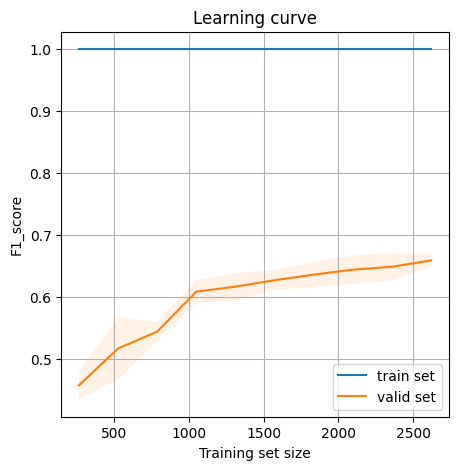

In [60]:
lgbm_pipeline = Pipeline([('preprocessing', PrepareData(regression_task=False)), ('model', LGBMClassifier(random_state=rnd_state, verbose=-1))])
plot_learning_curve(lgbm_pipeline, x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined, regression_task=False)

In [61]:
def objective_lgbm(trial):
    param_space = {
    'model__n_estimators': trial.suggest_int('model__n_estimators',100, 800),
    'model__learning_rate': trial.suggest_float('model__learning_rate', 0.01, 0.3, log=True),
    'model__max_depth': trial.suggest_int('model__max_depth', 2, 15),
    'model__min_child_samples': trial.suggest_int('model__min_child_samples', 2, 50),
    'model__subsample': trial.suggest_float('model__subsample', 0.5, 1.0),
    'model__colsample_bytree': trial.suggest_float('model__colsample_bytree', 0.5, 1.0),
    'model__reg_alpha': trial.suggest_float('model__reg_alpha', 1e-8, 10.0, log=True),
    'model__reg_lambda': trial.suggest_float('model__reg_lambda', 1e-8, 10.0, log=True),   
    'model__is_unbalance': trial.suggest_categorical('model__is_unbalance',[True]), 
        } 
    lgbm_pipeline.set_params(**param_space)
    score = cross_val_score(lgbm_pipeline, x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined, cv=3, n_jobs=-1, scoring='f1')
    return score.mean()

lgbm_sampler = TPESampler(seed=rnd_state)
study_lgbm = optuna.create_study(direction="maximize", sampler=lgbm_sampler)
study_lgbm.optimize(objective_lgbm, n_trials=12)
lgbm_pipeline.set_params(**study_lgbm.best_params)

print("Best hyperparameters: ", study_lgbm.best_params)
print("F1_score = ",study_lgbm.best_value)

Best hyperparameters:  {'model__n_estimators': 402, 'model__learning_rate': 0.05360838832794948, 'model__max_depth': 7, 'model__min_child_samples': 17, 'model__subsample': 0.7131756534814041, 'model__colsample_bytree': 0.9466945815585674, 'model__reg_alpha': 3.143693259084261, 'model__reg_lambda': 0.0003284959979640214, 'model__is_unbalance': True}
F1_score =  0.6976765245033997


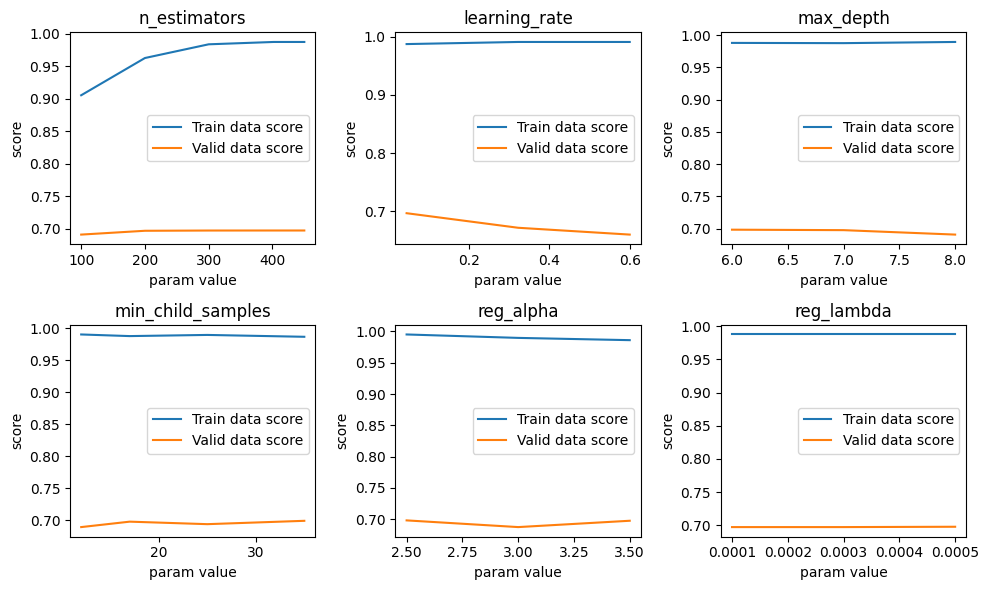

In [62]:
lgbm_param_space = {
    'model__n_estimators': [100,200,300,402,450],
    'model__learning_rate': np.linspace(0.045,0.6,3),
    'model__max_depth': [6,7,8],
    'model__min_child_samples': [12,17,25,35],
    'model__reg_alpha': np.linspace(2.5,3.5,3),
    'model__reg_lambda': np.linspace(0.0001, 0.0005, 3) 
}

plot_validation_curve(lgbm_pipeline, x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined, regression_task=False, params=lgbm_param_space)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best hyperparameters:  {'model__learning_rate': np.float64(0.2), 'model__max_depth': 6, 'model__min_child_samples': 18, 'model__n_estimators': 200}
F1 =  0.6890986741793051


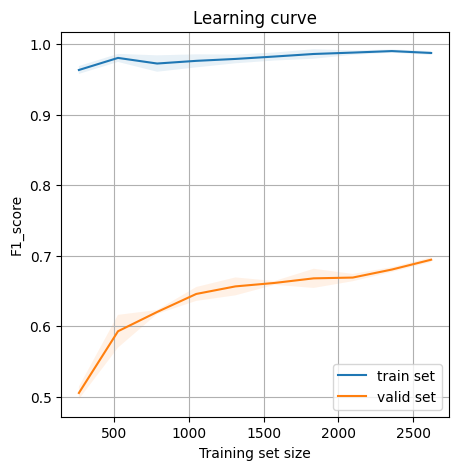

In [63]:
lgbm_param_space = {
    'model__n_estimators': [200,300,402],
    'model__learning_rate': np.linspace(0.03,0.54,4),
    'model__max_depth': [6,7],
    'model__min_child_samples': [16,17,18],
    }

cv_folds_lgbm = KFold(n_splits=3, shuffle=True, random_state=rnd_state)
lgbm_grid = GridSearchCV(lgbm_pipeline, cv =cv_folds_lgbm, param_grid=lgbm_param_space, scoring='f1', n_jobs=-1, verbose=1)
lgbm_grid.fit(x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined)
lgbm_final_model = lgbm_grid.best_estimator_

print("Best hyperparameters: ", lgbm_grid.best_params_)
print("F1 = ", lgbm_grid.best_score_)
plot_learning_curve(lgbm_final_model, x_combined.drop(["movie_title", "movie_imdb_link"],axis=1), y_combined, regression_task=False)

In [64]:
lgbm_results = cross_validate(lgbm_final_model, x_combined.drop(["movie_title", "movie_imdb_link"],axis=1), y_combined, cv=cv_folds_lgbm, scoring = {'f1': 'f1', 'precision': 'precision', 'balanced_accuracy': 'balanced_accuracy'})
lgbm_performance = {'f1': lgbm_results['test_f1'].mean(), 'precision': lgbm_results['test_precision'].mean(), 'balanced_accuracy': lgbm_results['test_balanced_accuracy'].mean()}
lgbm_performance

{'f1': np.float64(0.6890986741793051),
 'precision': np.float64(0.6756910063182504),
 'balanced_accuracy': np.float64(0.8166088714011521)}

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best hyperparameters:  {'model__learning_rate': np.float64(0.6611111111111111), 'model__max_depth': 6, 'model__min_child_samples': 18, 'model__n_estimators': 200}
F1 =  0.6733855190968034


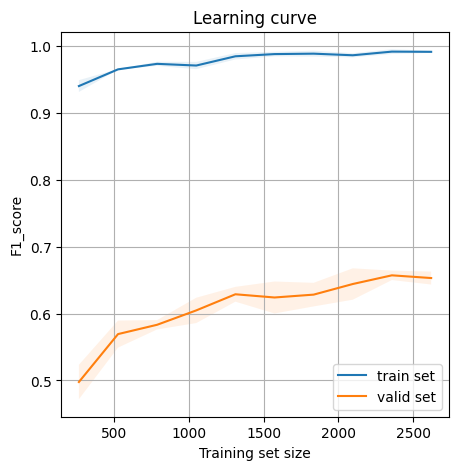

In [65]:
# try to  overfit model
lgbm_param_space_of = {
    'model__n_estimators': [200],
    'model__learning_rate': np.linspace(0.65,0.75,10),
    'model__max_depth': [6],
    'model__min_child_samples': [18],
    }

lgbm_grid_of = GridSearchCV(lgbm_pipeline, cv =cv_folds_lgbm, param_grid=lgbm_param_space_of, scoring='f1', n_jobs=-1, verbose=1)
lgbm_grid_of.fit(x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined)
lgbm_final_model_of = lgbm_grid_of.best_estimator_

print("Best hyperparameters: ", lgbm_grid_of.best_params_)
print("F1 = ", lgbm_grid_of.best_score_)
plot_learning_curve(lgbm_final_model_of, x_combined.drop(["movie_title", "movie_imdb_link"],axis=1), y_combined, regression_task=False)

#### 4.1.4 Logistic Regression

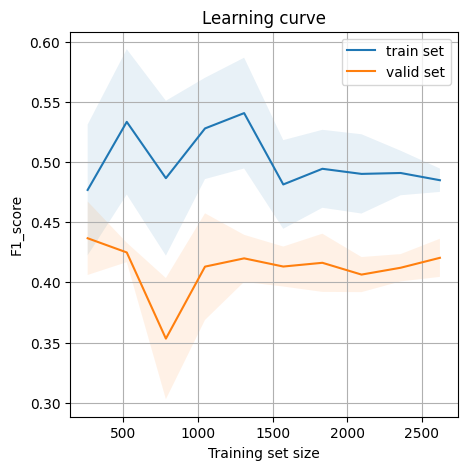

In [66]:
lr = LogisticRegression(random_state=rnd_state, max_iter = 1000, solver='saga')

log_transformer = FunctionTransformer(np.log1p, validate=True, feature_names_out="one-to-one")
column_log_transformer = ColumnTransformer(transformers=[('log', log_transformer, ['budget', "actor_1_facebook_likes", "actor_2_facebook_likes", "actor_3_facebook_likes",
                                           "movie_facebook_likes", "director_facebook_likes", "num_critic_for_reviews", "facenumber_in_poster", "war_symb_title", "gross"])], remainder="passthrough", verbose_feature_names_out=False)

scaler = ColumnTransformer(transformers=[('scaler', StandardScaler(), ["budget", "actor_1_facebook_likes", "actor_2_facebook_likes", "actor_3_facebook_likes", "movie_facebook_likes", "director_facebook_likes", "num_critic_for_reviews", "facenumber_in_poster",
                           "war_symb_title", "duration", "title_year", "gross", "point_symb_title", "genres_mean_target", "plot_keywords_mean_target", "actor_counts", "director_counts", "review_ratio"])], remainder="passthrough", verbose_feature_names_out=False)

lr_pipeline = Pipeline([('preprocessing', PrepareData(regression_task=False)),('imputer', SimpleImputer(strategy='median')), ('log_trainsormer', column_log_transformer),('scaler', scaler), ('model', lr)])
plot_learning_curve(lr_pipeline, x_combined.drop(["movie_title", "movie_imdb_link"],axis=1), y_combined, regression_task=False)

In [67]:
SCALERS = {
    'StandardScaler': StandardScaler(),
    'RobustScaler': RobustScaler(),
    'MinMaxScaler': MinMaxScaler()
}

def objective_lr(trial):

    scaler_name = trial.suggest_categorical('scaler__scaler', ['StandardScaler', 'RobustScaler', 'MinMaxScaler'])
    
    param_space = {
        "model__C": trial.suggest_float('model__C', 0.01, 10, log=True),
        "model__l1_ratio": trial.suggest_float('model__l1_ratio', 0.001,1),
        "model__class_weight": trial.suggest_categorical('model__class_weight', [None, "balanced"]),
        "imputer__strategy": trial.suggest_categorical('imputer__strategy', ["mean", "median", "constant"]),
        "imputer__add_indicator": trial.suggest_categorical('imputer__add_indicator', [False, True]),
        "scaler__scaler": SCALERS[scaler_name]
    }

    lr_pipeline.set_params(**param_space)
    scores = cross_val_score(lr_pipeline, x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined, cv=3, scoring="f1", n_jobs=-1)
    
    return scores.mean()

lr_sampler = TPESampler(seed=rnd_state)
study_lr = optuna.create_study(direction="maximize", sampler=lr_sampler)
study_lr.optimize(objective_lr, n_trials=100)
best_params = study_lr.best_params.copy()
best_params['scaler__scaler'] = SCALERS[best_params['scaler__scaler']]
lr_pipeline.set_params(**best_params)

print("Best hyperparameters: ", study_lr.best_params)
print("F1_score = ",study_lr.best_value)

/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The ma

Best hyperparameters:  {'scaler__scaler': 'RobustScaler', 'model__C': 5.225899154924628, 'model__l1_ratio': 0.7775603090304485, 'model__class_weight': 'balanced', 'imputer__strategy': 'mean', 'imputer__add_indicator': True}
F1_score =  0.5834493059374438


/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The ma

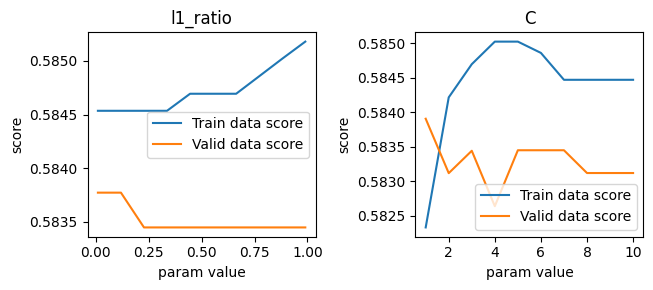

In [68]:
lr_param_space = {
    'model__l1_ratio': np.linspace(0.01,0.99,10),
    'model__C': [1,2,3,4,5,6,7,8,9,10]
}

plot_validation_curve(lr_pipeline, x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined, params=lr_param_space, regression_task=False)

/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The ma

Best hyperparameters:  {'model__C': np.float64(4.8), 'model__l1_ratio': np.float64(0.75)}
F1:  0.577613209677618


/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The ma

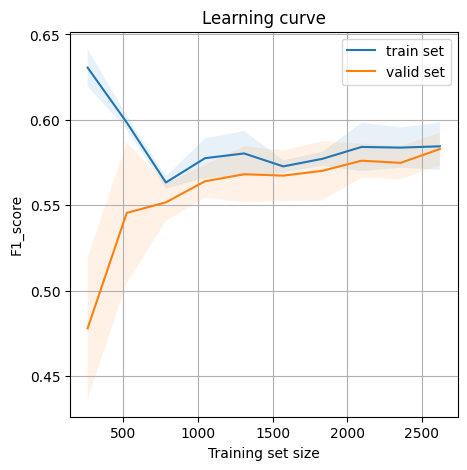

In [69]:
lr_param_grid = {
    'model__l1_ratio': np.linspace(0.75,0.8,10),
    'model__C': np.linspace(4.8, 5.4,10)
}

cv_folds_lr = KFold(n_splits=3, shuffle = True, random_state=rnd_state)
lr_grid = GridSearchCV(lr_pipeline, cv=cv_folds_lr, param_grid=lr_param_grid, scoring='f1', n_jobs=-1, verbose=0)
lr_grid.fit(x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined)
lr_final_model = lr_grid.best_estimator_

print("Best hyperparameters: ", lr_grid.best_params_)
print("F1: ", lr_grid.best_score_)
plot_learning_curve(lr_final_model, x_combined.drop(["movie_title", "movie_imdb_link"],axis=1), y_combined, regression_task=False)

In [70]:
lr_results = cross_validate(lr_final_model, x_combined.drop(["movie_title", "movie_imdb_link"],axis=1), y_combined, cv=cv_folds_lr, scoring = {'f1': 'f1', 'precision': 'precision', 'balanced_accuracy': 'balanced_accuracy'})
lr_performance = {'f1': lr_results['test_f1'].mean(), 'precision': lr_results['test_precision'].mean(), 'balanced_accuracy': lr_results['test_balanced_accuracy'].mean()}
lr_performance

/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


{'f1': np.float64(0.577613209677618),
 'precision': np.float64(0.47001342779815464),
 'balanced_accuracy': np.float64(0.7871220756441316)}

In [71]:
coefs = lr_final_model['model'].coef_[0]
features = lr_final_model['scaler'].get_feature_names_out()
pd.DataFrame({'Feature': features, 'coef': coefs}).sort_values(by='coef')

,Feature,coef
28,is_aspect_ratio_2.35,-0.9356
21,is_english,-0.9163
20,is_USA,-0.5285
0,budget,-0.5104
10,title_year,-0.4471
34,missingindicator_gross,-0.4429
29,is_color,-0.4332
27,is_aspect_ratio_1.85,-0.4323
23,is_rating_PG-13,-0.2960
7,facenumber_in_poster,-0.2066


#### 4.1.4 CatBoost

In [72]:
class PrepareData_catboost(BaseEstimator, TransformerMixin):
    def __init__(self, regression_task = True):

        self.unrated_names = ['Unrated', 'Not Rated']
        self.regression_task = regression_task
    
    def _calc_combo(self, genres_str):
        """
        calculate average budget for combined movie genres
        """
        if pd.isna(genres_str):
            return self.global_budget_median_
        
        genres = genres_str.split("|")
        vals = []
        for g in genres:
            val = self.genre_budget_medians_.get(g, self.global_budget_median_)
            if pd.isna(val): 
                val = self.global_budget_median_
            vals.append(val)        
        return np.mean(vals)
    
    def fit(self,X,y):
        # non-numerical data
        if not self.regression_task: 
            y= X['imdb_score']
            

        self.actor_counts_ = pd.concat([X.actor_1_name, X.actor_2_name, X.actor_3_name]).dropna().value_counts()
        self.director_counts_ = X.director_name.dropna().value_counts()

        df_budget = pd.DataFrame({'genres': X.genres, 'budget': X.budget})
        df_budget['genres'] = df_budget.genres.fillna("Unknown").str.split("|")
        df_budget = df_budget.explode("genres")

        self.genre_budget_medians_ = df_budget.groupby('genres')['budget'].median().to_dict()
        self.global_budget_median_ = df_budget['budget'].median()

        return self 

    def transform(self, X):
        X_copy = X.copy()
        
        # missing values
        X_copy["is_missing_budget"] = X_copy['budget'].isna().astype(int)
        X_copy.loc[X_copy['budget'].isna(),'budget'] = X_copy.loc[X_copy['budget'].isna(), 'genres'].apply(self._calc_combo)

        X_copy["is_missing_rating"] = X_copy.content_rating.isna().astype(int)
        X_copy.loc[X_copy.content_rating.isna(), "content_rating"] = "Unrated"

        X_copy["num_user_for_reviews"] = X_copy["num_user_for_reviews"].fillna(0)
        X_copy["num_critic_for_reviews"] = X_copy["num_critic_for_reviews"].fillna(0)

        
        X_copy["actor_counts"] = X.actor_1_name.map(self.actor_counts_).fillna(0) + X.actor_2_name.map(self.actor_counts_).fillna(0) + X.actor_3_name.map(self.actor_counts_).fillna(0)
        X_copy["director_counts"] = X.director_name.map(self.director_counts_).fillna(0)

        X_copy.content_rating = X_copy.content_rating.replace(self.unrated_names, "Unrated")
        

        X_copy["review_ratio"] = (X_copy["num_user_for_reviews"] / X_copy["num_voted_users"])

        X_copy["genres"] = X_copy["genres"].fillna("Unknown").str.replace("|", " ")
        X_copy["plot_keywords"] = X_copy["plot_keywords"].fillna("Unknown").str.replace("|", " ")

        cat_cols = ['country', 'language', 'color', 'content_rating', 'aspect_ratio']
        for col in cat_cols:
            if col in X_copy.columns:
                X_copy[col] = X_copy[col].fillna("Unknown").astype(str)

        
        X_copy = X_copy.drop(["actor_1_name", "actor_2_name", "actor_3_name", "director_name", "num_user_for_reviews", "num_voted_users"],axis=1)
        if not self.regression_task:
            X_copy = X_copy.drop(["imdb_score"], axis=1)

        return X_copy

/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


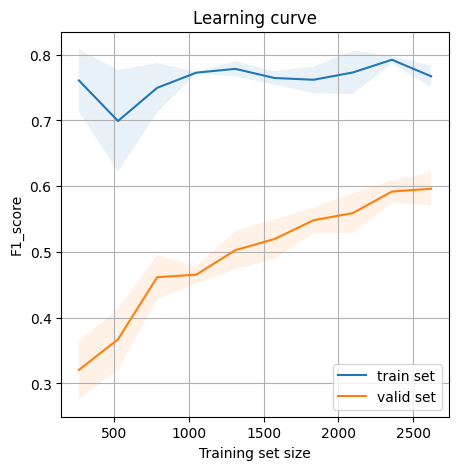

In [73]:
cat_features = ("color", "content_rating", "aspect_ratio", "country", "language")
text_features = ("genres", "plot_keywords")
cb_pipeline = Pipeline([('preprocessing', PrepareData_catboost(regression_task=False)), ('model', CatBoostClassifier(random_state=rnd_state, cat_features=cat_features, text_features=text_features, iterations=100, verbose=0))])
plot_learning_curve(cb_pipeline, x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined, regression_task=False)

In [74]:
def objective_cb(trial):
    param_space = {
        'model__iterations': trial.suggest_int('model__iterations', 100, 500),
        'model__learning_rate': trial.suggest_float('model__learning_rate', 0.01, 0.3, log=True),
        'model__depth': trial.suggest_int('model__depth', 2, 10),
        'model__l2_leaf_reg': trial.suggest_float('model__l2_leaf_reg', 1.0, 10.0, log=True),
        'model__random_strength': trial.suggest_float('model__random_strength', 0.001, 10.0, log=True),
        'model__bagging_temperature': trial.suggest_float('model__bagging_temperature', 0.0, 1.0),
        'model__border_count': trial.suggest_int('model__border_count', 32, 200)
        } 
    cb_pipeline.set_params(**param_space)
    score = cross_val_score(cb_pipeline, x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined, cv=3, n_jobs=-1, scoring='f1')
    return score.mean()

cb_sampler = TPESampler(seed=rnd_state)
study_cb = optuna.create_study(direction="maximize", sampler=cb_sampler)
study_cb.optimize(objective_cb, n_trials=5)
cb_pipeline.set_params(**study_cb.best_params)

print("Best hyperparameters: ", study_cb.best_params)
print("F1_score = ",study_cb.best_value)

Best hyperparameters:  {'model__iterations': 440, 'model__learning_rate': 0.11751907337909233, 'model__depth': 7, 'model__l2_leaf_reg': 5.277683990040606, 'model__random_strength': 0.019581035528392247, 'model__bagging_temperature': 0.3617886556223141, 'model__border_count': 70}
F1_score =  0.6217032212989994


In [75]:
cb_final_model = cb_pipeline
cv_folds_cb = KFold(n_splits=3, shuffle = True, random_state=rnd_state)
cb_results = cross_validate(cb_final_model, x_combined.drop(["movie_title", "movie_imdb_link"],axis=1), y_combined, cv=cv_folds_cb, scoring = {'f1': 'f1', 'precision': 'precision', 'balanced_accuracy': 'balanced_accuracy'})
cb_performance = {'f1': cb_results['test_f1'].mean(), 'precision': cb_results['test_precision'].mean(), 'balanced_accuracy': cb_results['test_balanced_accuracy'].mean()}
cb_final_model.fit(x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined)
cb_performance

{'f1': np.float64(0.626699122490684),
 'precision': np.float64(0.7802215701677372),
 'balanced_accuracy': np.float64(0.7468188324598225)}

#### 4.1.6 SVC

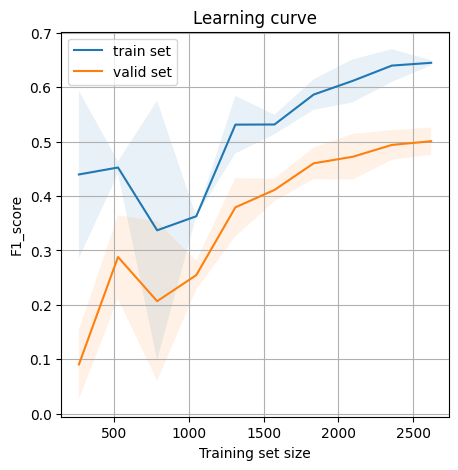

In [76]:
svc = SVC(random_state=rnd_state)
svc_pipeline = Pipeline([('preprocessing', PrepareData(regression_task=False)),('imputer', SimpleImputer(strategy='median')), ('log_trainsormer', column_log_transformer),('scaler', scaler), ('model', svc)])
plot_learning_curve(svc_pipeline, x_combined.drop(["movie_title", "movie_imdb_link"],axis=1), y_combined, regression_task=False)

In [77]:
def objective_svc(trial):

    scaler_name = trial.suggest_categorical('scaler__scaler', ['StandardScaler', 'RobustScaler', 'MinMaxScaler'])
    
    param_space = {
        'model__C': trial.suggest_float('model__C',0.01,8, log=True),
        'model__gamma': trial.suggest_categorical('model__gamma', ['scale', 'auto', 0.2, 0.1, 0.01, 0.001, 0.0001]),
        'model__kernel': trial.suggest_categorical('model__kernel', ['sigmoid', 'rbf']),
        'model__degree': trial.suggest_int('model__degree', 2,5),
        'imputer__strategy': trial.suggest_categorical('imputer__strategy', ['median', 'mean', 'constant']),
        'imputer__add_indicator': trial.suggest_categorical('imputer__add_indicator', [True, False]),
        'scaler__scaler': SCALERS[scaler_name]
    }

    svc_pipeline.set_params(**param_space)
    scores = cross_val_score(svc_pipeline, x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined, cv=3, scoring="f1", n_jobs=-1)
    
    return scores.mean()

svc_sampler = TPESampler(seed=rnd_state)
study_svc = optuna.create_study(direction="maximize", sampler=svc_sampler)
study_svc.optimize(objective_svc, n_trials=400)
best_params = study_svc.best_params.copy()
best_params['scaler__scaler'] = SCALERS[best_params['scaler__scaler']]
svc_pipeline.set_params(**best_params)

print("Best hyperparameters: ", study_svc.best_params)
print("F1_score = ",study_svc.best_value)

Best hyperparameters:  {'scaler__scaler': 'RobustScaler', 'model__C': 5.843599081718372, 'model__gamma': 0.1, 'model__kernel': 'rbf', 'model__degree': 3, 'imputer__strategy': 'mean', 'imputer__add_indicator': True}
F1_score =  0.5960033563753235


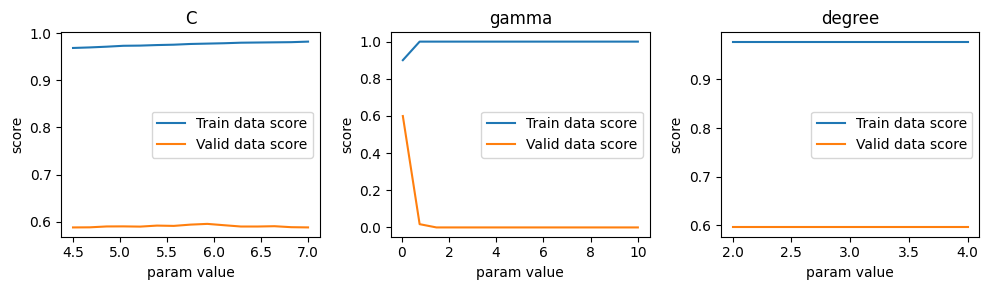

In [78]:
svc_param_space = {
    'model__C': np.linspace(4.5,7,15),
    'model__gamma': np.linspace(0.05,10,15),
    'model__degree': [2,3,4]
}

plot_validation_curve(svc_pipeline, x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined, params=svc_param_space, regression_task=False)

Fitting 3 folds for each of 300 candidates, totalling 900 fits
Best hyperparameters:  {'model__gamma': np.float64(0.057869565217391304)}
F1:  0.6020328082798571


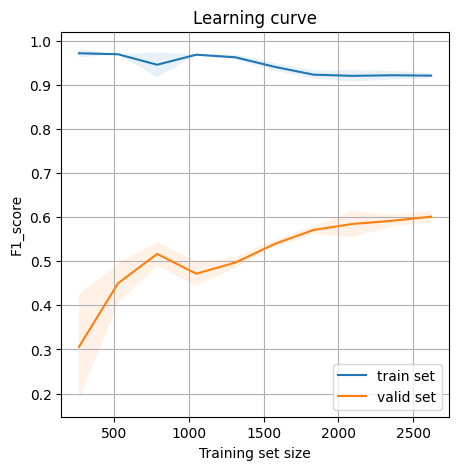

In [79]:
svc_param_grid = {
    'model__gamma': np.linspace(0.001,0.11,300),
}

cv_folds_svc = KFold(n_splits=3, shuffle = True, random_state=rnd_state)
svc_grid = GridSearchCV(svc_pipeline, cv=cv_folds_svc, param_grid=svc_param_grid, scoring='f1', n_jobs=-1, verbose=1, error_score='raise')
svc_grid.fit(x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined)
svc_final_model = svc_grid.best_estimator_

print("Best hyperparameters: ", svc_grid.best_params_)
print("F1: ", svc_grid.best_score_)
plot_learning_curve(svc_final_model, x_combined.drop(["movie_title", "movie_imdb_link"],axis=1), y_combined, regression_task=False)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best hyperparameters:  {'model__C': np.float64(20.0), 'model__gamma': np.float64(0.1)}
F1:  0.5719286902536997


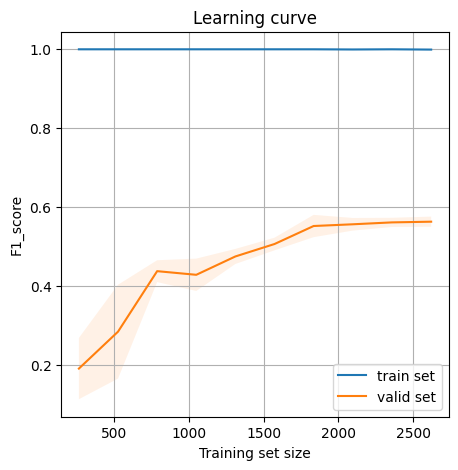

In [80]:
svc_param_grid_of = {
    'model__C': np.linspace(20, 30,5),
    'model__gamma': np.linspace(0.1,0.2,5),
}

svc_grid_of = GridSearchCV(svc_pipeline, cv=cv_folds_svc, param_grid=svc_param_grid_of, scoring='f1', n_jobs=-1, verbose=1, error_score='raise')
svc_grid_of.fit(x_combined.drop(["movie_title", "movie_imdb_link"], axis=1), y_combined)
svc_final_model_of = svc_grid_of.best_estimator_

print("Best hyperparameters: ", svc_grid_of.best_params_)
print("F1: ", svc_grid_of.best_score_)
plot_learning_curve(svc_final_model_of, x_combined.drop(["movie_title", "movie_imdb_link"],axis=1), y_combined, regression_task=False)

In [81]:
svc_results = cross_validate(svc_final_model, x_combined.drop(["movie_title", "movie_imdb_link"],axis=1), y_combined, cv=cv_folds_svc, scoring = {'f1': 'f1', 'precision': 'precision', 'balanced_accuracy': 'balanced_accuracy'})
svc_performance = {'f1': svc_results['test_f1'].mean(), 'precision': svc_results['test_precision'].mean(), 'balanced_accuracy': svc_results['test_balanced_accuracy'].mean()}
svc_performance

{'f1': np.float64(0.6020328082798571),
 'precision': np.float64(0.702440385878541),
 'balanced_accuracy': np.float64(0.7406765940060396)}

### 4.2 Results analysis

In [82]:
# mean results from crossvalidation on train+valid set
results = {'XGBosst': xgb_performance, 'LightGBM': lgbm_performance, 'LogisticRegression': lr_performance, 'CatBoost': cb_performance, 'SVC': svc_performance}
results = pd.DataFrame(results)
results

,XGBosst,LightGBM,LogisticRegression,CatBoost,SVC
f1,0.6677,0.6891,0.5776,0.6267,0.6020
precision,0.7789,0.6757,0.4700,0.7802,0.7024
balanced_accuracy,0.7750,0.8166,0.7871,0.7468,0.7407


In [83]:
# test set results

test_results = {
    'Baseline': evaluate_model(y_test, baseline.predict(x_test.drop(["movie_title", "movie_imdb_link"], axis=1)), regression_task=False),
    'XGBosst': evaluate_model(y_test, xgb_final_model.predict(x_test.drop(["movie_title", "movie_imdb_link"], axis=1)), regression_task=False),
    'LightGBM': evaluate_model(y_test, lgbm_final_model.predict(x_test.drop(["movie_title", "movie_imdb_link"], axis=1)), regression_task=False),
    'LogisticRegression': evaluate_model(y_test, lr_final_model.predict(x_test.drop(["movie_title", "movie_imdb_link"], axis=1)), regression_task=False),
    'CatBoost': evaluate_model(y_test, cb_final_model.predict(x_test.drop(["movie_title", "movie_imdb_link"], axis=1)), regression_task=False),
    'SVC': evaluate_model(y_test, svc_final_model.predict(x_test.drop(["movie_title", "movie_imdb_link"], axis=1)), regression_task=False)
    }
test_results = pd.DataFrame(test_results)
test_results

F1_score:  0.261 
Precision_score:  0.667 
Balanced_accuracy:  0.572
F1_score:  0.653 
Precision_score:  0.702 
Balanced_accuracy:  0.775
F1_score:  0.672 
Precision_score:  0.639 
Balanced_accuracy:  0.808
F1_score:  0.617 
Precision_score:  0.507 
Balanced_accuracy:  0.806
F1_score:  0.632 
Precision_score:  0.784 
Balanced_accuracy:  0.748
F1_score:  0.577 
Precision_score:  0.667 
Balanced_accuracy:  0.725


,Baseline,XGBosst,LightGBM,LogisticRegression,CatBoost,SVC
F1,0.2609,0.6532,0.6718,0.6173,0.6323,0.5767
Precision,0.6667,0.7019,0.6390,0.5069,0.7840,0.6667
Balanced_accuracy,0.5717,0.7754,0.8077,0.8057,0.7480,0.7246


In [84]:
models = {
    "XGB": xgb_final_model,
    "LGBM": lgbm_final_model,
    "LR": lr_final_model,
    "CB": cb_final_model,
    "SVC": svc_final_model,
    "Baseline": baseline
}

metrics = {
    "f1": f1_score,
    'precision': precision_score,
    "balanced_accuracy": balanced_accuracy_score,
}

results = {m_name: {met_name: [] for met_name in metrics} for m_name in models}

parts_x = np.array_split(x_test, 10)
parts_y = np.array_split(y_test, 10)

for i in range(len(parts_x)):
    x_test_i = pd.DataFrame(parts_x[i], columns=x_valid.columns).astype(x_valid.dtypes)
    x_test_i.drop(["movie_title", "movie_imdb_link"], axis=1, inplace=True)
    y_true = parts_y[i]

    for model_name, model in models.items():
        preds = model.predict(x_test_i)
        
        for met_name, met_func in metrics.items():
            score = met_func(y_true, preds)
            results[model_name][met_name].append(score)

In [85]:
# Friedman's test with baseline
print("Friedman's test with baseline:")
# H0: There is no significant difference between the performances of the models
# H1: There is significant difference between the performances of the models

# F1_score
stat, p_value = stats.friedmanchisquare(results["Baseline"]["f1"], results["XGB"]["f1"], results["LGBM"]["f1"], results["LR"]["f1"], results["CB"]["f1"], results["SVC"]["f1"])
print(f"F1_score p_value: {p_value:.4f}")

# Precision
stat, p_value = stats.friedmanchisquare(results["Baseline"]["precision"], results["XGB"]["precision"], results["LGBM"]["precision"], results["LR"]["precision"], results["CB"]["precision"], results["SVC"]["precision"])
print(f"Precision p_value: {p_value:.4f}")

# Balanced accuracy
stat, p_value = stats.friedmanchisquare(results["Baseline"]["balanced_accuracy"], results["XGB"]["balanced_accuracy"], results["LGBM"]["balanced_accuracy"], results["LR"]["balanced_accuracy"], results["CB"]["balanced_accuracy"], results["SVC"]["balanced_accuracy"])
print(f"Balanced accuracy p_value: {p_value:.4f}")

# We reject the null hypothesis for all metric. There is no significant difference between model

Friedman's test with baseline:
F1_score p_value: 0.0000
Precision p_value: 0.0005
Balanced accuracy p_value: 0.0000


In [86]:
# Friedman's test without baseline
print("Friedman's test without baseline:")
# H0: There is no significant difference between the performances of the models
# H1: There is significant difference between the performances of the models

# F1_score
stat, p_value = stats.friedmanchisquare(results["XGB"]["f1"], results["LGBM"]["f1"], results["LR"]["f1"], results["CB"]["f1"], results["SVC"]["f1"])
print(f"F1_score p_value: {p_value:.4f}")

# Precision
stat, p_value = stats.friedmanchisquare(results["XGB"]["precision"], results["LGBM"]["precision"], results["LR"]["precision"], results["CB"]["precision"], results["SVC"]["precision"])
print(f"Precision p_value: {p_value:.4f}")

# Balanced accuracyś
stat, p_value = stats.friedmanchisquare(results["XGB"]["balanced_accuracy"], results["LGBM"]["balanced_accuracy"], results["LR"]["balanced_accuracy"], results["CB"]["balanced_accuracy"], results["SVC"]["balanced_accuracy"])
print(f"Balanced accuracy p_value: {p_value:.4f}")

# We reject the null hypothesis for precision and balanced accuracy. There is significant difference between models for these metrics
# We fail to reject the null hypothesis for f1 score. There is no sifinificant difference between models for f1_score.

Friedman's test without baseline:
F1_score p_value: 0.0639
Precision p_value: 0.0000
Balanced accuracy p_value: 0.0004


In [87]:
# Nemenyi-Firedman's posthoc test for balanced accuracy
print("# Nemenyi-Firedman's posthoc test for balanced accuracy")
# H0: There is no siginificant difference between model 1 and model 2
# H1: There is siginificant difference between model 1 and model 2

res = pd.DataFrame({
    'Baseline': results["Baseline"]["balanced_accuracy"],
    'XGBoost': results["XGB"]["balanced_accuracy"], 
    'LightGBM': results["LGBM"]["balanced_accuracy"], 
    'LogisticRegression': results["LR"]["balanced_accuracy"],
    'CatBoost': results["CB"]["balanced_accuracy"],
    'SVC': results["SVC"]["balanced_accuracy"]
})

posthoc_results = sp.posthoc_nemenyi_friedman(res)
posthoc_results

# There is no siginificant difference between lightGBM, XGBoost, LogisitcRegression, CatBoost and SVC at the 0.05 significant level.
# There is significant differnce between baseline and XGBoost, LightGBM and LogisticRegression

# Nemenyi-Firedman's posthoc test for balanced accuracy


,Baseline,XGBoost,LightGBM,LogisticRegression,CatBoost,SVC
Baseline,1.0000,0.0056,0.0000,0.0000,0.0902,0.3584
XGBoost,0.0056,1.0000,0.5895,0.8667,0.9475,0.6292
LightGBM,0.0000,0.5895,1.0000,0.9969,0.1211,0.0192
LogisticRegression,0.0000,0.8667,0.9969,1.0000,0.3241,0.0773
CatBoost,0.0902,0.9475,0.1211,0.3241,1.0000,0.9864
SVC,0.3584,0.6292,0.0192,0.0773,0.9864,1.0000


### 4.3 Training time comparison

In [88]:
models = [baseline, xgb_final_model, lgbm_final_model, lr_final_model, cb_final_model, svc_final_model]
results = []

for model in models:
    model_copy = clone(model)
    x_preprocessed = model[:-1].transform(X.drop(["movie_title", "movie_imdb_link"], axis=1))
    estimator = model_copy[-1]

    start = time.perf_counter()
    estimator.fit(x_preprocessed, y)
    end = time.perf_counter()

    duration = end - start
    results.append(duration)
print("Training time without preprocessing: ", "\nBaseline: ", results[0],"\nXGB: ", results[1] ,"\nLightGBM: ", results[2],"\nLogistic Regression: ", results[3],"\nCatBoost: ", results[4],"\nSVC: ", results[5])
# 1. SVC, 2. Baseline 3. XGB, 4. LightGBM, 5.Logisitc Regression, 6. Catboost

/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Training time without preprocessing:  
Baseline:  0.23583995800004232 
XGB:  0.6685264579998602 
LightGBM:  0.657026500000029 
Logistic Regression:  1.2679510000000391 
CatBoost:  21.840268917000003 
SVC:  0.17165083399981995


In [89]:
# lightgbm achieved the best result on the test set (in term of f1 and balanced accuracy), while the baseline and svc the worst
# Freidman's test revealed significant differences between models (except for the test without baselibe using f1_score)
# post-hoc test using balanced accuracy showed no significant differences between lighGBM, XGBoost, Logistic Regression
# simultaneously, tests indicated no siginificant differnce between baseline, catboost and svc
# In terms of training time, the baseline and SVC were the fastest, whereas catboost was much slower than other models 
# taking into account the best results on the test set and relatively short learing time I have selected lightGBM as the final model

### 4.4 Error analysis

In [90]:
lgbm_test_preds = lgbm_final_model.predict(x_test.drop(["movie_title", "movie_imdb_link"], axis=1))
print("-----Error analysis-----")
print("Number of instances where imdb_score >= 7.5 (postive calss): ", len(x_test.iloc[1 == y_test, :]))
print("Number of correct predictions: ", len(x_test.iloc[lgbm_test_preds == y_test, :])) 
print("Number of incorrect prediciotns: ", len(x_test.iloc[lgbm_test_preds != y_test, :])) 
print("Number of incorrect predictions where imdb score was betwwen 7 and 8: ", len(x_test.iloc[(lgbm_test_preds != y_test) & ((x_test.imdb_score >= 7)  & (x_test.imdb_score <= 8)), :]))
print("Number of incorrect predicitons where imdb score > 8: ",len(x_test.iloc[(lgbm_test_preds != y_test) & (x_test.imdb_score > 8), :]))
print("Number of incorrect predicions where imdb score < 7: ", len(x_test.iloc[(lgbm_test_preds != y_test) & (x_test.imdb_score < 7), :]))
print("Number of instances where imdb score was betwwen 7 and 8: ", len(x_test.iloc[((x_test.imdb_score >= 7)  & (x_test.imdb_score <= 8)), :]))

# The model's performance is highly dependent on the imdb score value.
# Most of the errors (nearly 83%) occured in instances where true value of imdb score is close to the treshold (betweend 7 and 8)
# Outside this range, the model performs very well.

-----Error analysis-----
Number of instances where imdb_score >= 7.5 (postive calss):  185
Number of correct predictions:  856
Number of incorrect prediciotns:  128
Number of incorrect predictions where imdb score was betwwen 7 and 8:  106
Number of incorrect predicitons where imdb score > 8:  5
Number of incorrect predicions where imdb score < 7:  17
Number of instances where imdb score was betwwen 7 and 8:  304


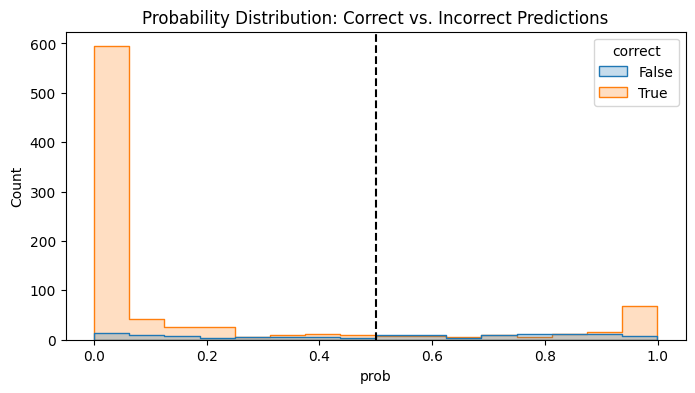

In [91]:
probs = lgbm_final_model.predict_proba(x_test.drop(["movie_title", "movie_imdb_link"], axis=1))[:, 1]
results_df = pd.DataFrame({'true': y_test, 'prob': probs})
results_df['correct'] = (results_df['true'] == (results_df['prob'] > 0.5))

plt.figure(figsize=(8, 4))
sns.histplot(data=results_df, x='prob', hue='correct', element='step', common_norm=False)
plt.title('Probability Distribution: Correct vs. Incorrect Predictions')
plt.axvline(0.5, color='black', linestyle='--') 
plt.show()

# the plots shows that when the model is certian, its predictions are usually correct. The model struggles the most when the probability is between 0.5 and 0.9

In [120]:
results_df.loc[results_df.correct == 0, "true"].value_counts()

true
0    74
1    54
Name: count, dtype: int64

In [92]:
results_df['error'] = abs(results_df['true'] - results_df['prob'])
results_df.index = y_test.index
ind = results_df.sort_values(by="error", ascending=False).head(15).index
errors = pd.concat([x_test.loc[ind,:], results_df.loc[ind]], axis=1)
errors

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,war_symb_title,point_symb_title,true,prob,correct,error
2976,Color,William H. Macy,44.0000,105.0000,0.0000,394.0000,Felicity Huffman,745.0000,37440.0000,Comedy|Drama|Music,Billy Crudup,Rudderless,12672,David Adam Flannery,1.0000,demo tape|directed by cast member|grieving fat...,http://www.imdb.com/title/tt1798243/?ref_=fn_t...,60.0000,English,USA,R,5000000.0000,2014.0000,508.0000,7.5000,NaN,0,2,0,1,0.0007,False,0.9993
1746,Color,Andrucha Waddington,42.0000,115.0000,6.0000,24.0000,Seu Jorge,119.0000,NaN,Drama,Fernanda Montenegro,House of Sand,2650,Fernanda Torres,1.0000,1910s|desert|dunes|goat|slave,http://www.imdb.com/title/tt0373747/?ref_=fn_t...,35.0000,Portuguese,Brazil,R,8000000.0000,2005.0000,69.0000,7.5000,2.3500,385,1,0,1,0.0007,False,0.9993
4323,Color,Justin Paul Miller,1.0000,90.0000,0.0000,33.0000,Jennifer Landa,84.0000,NaN,Comedy|Mystery|Thriller,Mary Kate Wiles,The Sound and the Shadow,30,Felix Avitia,0.0000,NaN,http://www.imdb.com/title/tt2190180/?ref_=fn_t...,1.0000,English,USA,R,NaN,2014.0000,41.0000,8.3000,NaN,70,3,0,1,0.0028,False,0.9972
3699,Color,Steve Box,209.0000,85.0000,9.0000,100.0000,Geraldine McEwan,567.0000,56068547.0000,Animation|Comedy|Family|Mystery|Sci-Fi,Mark Gatiss,The Curse of the Were-Rabbit,98160,Peter Sallis,0.0000,competition|giant vegetable|pest control|stop ...,http://www.imdb.com/title/tt0312004/?ref_=fn_t...,307.0000,English,UK,G,30000000.0000,2005.0000,269.0000,7.5000,1.8500,0,5,0,1,0.0048,False,0.9952
3208,Color,Kevin Jordan,21.0000,90.0000,4.0000,113.0000,Christa Miller,20000.0000,277233.0000,Comedy|Romance,Derick Martini,Smiling Fish & Goat on Fire,2631,Ion Overman,5.0000,accountant|actor|animal in title|mail carrier|...,http://www.imdb.com/title/tt0162348/?ref_=fn_t...,26.0000,English,USA,R,40000.0000,1999.0000,467.0000,7.6000,1.8500,0,2,0,1,0.0168,False,0.9832
2915,Color,Richard Loncraine,56.0000,104.0000,12.0000,1000.0000,Jim Broadbent,21000.0000,2600000.0000,Drama|War,Robert Downey Jr.,Richard III,11612,Kristin Scott Thomas,3.0000,1930s|abuse of power|england|king|murder,http://www.imdb.com/title/tt0114279/?ref_=fn_t...,88.0000,English,UK,R,6000000.0000,1995.0000,1000.0000,7.5000,2.3500,0,3,0,1,0.0183,False,0.9817
4556,Color,Marco Kreuzpaintner,69.0000,120.0000,7.0000,289.0000,Kate del Castillo,662.0000,214202.0000,Crime|Drama|Thriller,Zack Ward,Trade,14831,Alicja Bachleda,0.0000,friend|girl|mexico city|new jersey|sex,http://www.imdb.com/title/tt0399095/?ref_=fn_t...,75.0000,English,Germany,R,12000000.0000,2007.0000,345.0000,7.5000,2.3500,0,2,0,1,0.0224,False,0.9776
4899,Color,Kathryn Bigelow,558.0000,157.0000,0.0000,304.0000,Harold Perrineau,1000.0000,95720716.0000,Drama|History|Thriller,Jennifer Ehle,Zero Dark Thirty,216032,Parker Sawyers,0.0000,al qaeda|cia|interrogation|lie|navy seal,http://www.imdb.com/title/tt1790885/?ref_=fn_t...,640.0000,English,USA,R,40000000.0000,2012.0000,1000.0000,7.4000,1.8500,39000,4,0,0,0.9775,False,0.9775
2327,Color,Albert Hughes,28.0000,97.0000,117.0000,556.0000,Larenz Tate,851.0000,27900000.0000,Crime|Drama|Thriller,Jada Pinkett Smith,Menace II Society,39508,Khandi Alexander,2.0000,1990s|escape|graduation|hustler|street,http://www.imdb.com/title/tt0107554/?ref_=fn_t...,96.0000,English,USA,R,3500000.0000,1993.0000,582.0000,7.5000,1.8500,0,1,0,1,0.0261,False,0.9739
3006,Color,Michael McGowan,47.0000,98.0000,12.0000,149.0000,Adam Butcher,393.0000,795126.0000,Comedy|Drama|Sport,Campbell Scott,Saint Ralph,4976,Gordon Pinsent,1.0000,boston marathon|coma|marathon|miracles|running,http://www.imdb.com/title/tt0384488/?ref_=fn_t...,52.0000,English,Canada,PG-13,6000000.

In [ ]:
actual_model = lgbm_final_model[-1] 
X_test_transformed = lgbm_final_model[:-1].transform(x_test.drop(["movie_title", "movie_imdb_link"], axis=1))
explainer = shap.TreeExplainer(actual_model)
shap_values = explainer.shap_values(X_test_transformed)
expected_value = explainer.expected_value

int_indices = [x_test.index.get_loc(i) for i in ind]
error_pos = int_indices[14]
row_x = X_test_transformed.iloc[error_pos, :]
row_shap = shap_values[error_pos, :]

shap.initjs()
shap.force_plot(expected_value, row_shap, row_x)

# false-negative (imdb_score >= 7.5, our prediction is 0):
# 0: title_year = 2014, duration = 105, num_critic_for_review = 44
# 1: review_ratio = 0.001, movie_facebook_likes = 385, num_critic_for_reviews = 42
# 2: genres_mean_target = 6.31, review_ratio = 0.03, movie_facebook_likes = 70
# 3: genres_mean_target = 6.34, gross=5.6e+7, polt_keywords_mean_target = 6.2
# 4: genres_mean_target = 6.3, num_critic_for_reviews = 21, acotr_1_facebook_likes = 467
# 5: num_critic_for_reviews = 56, duration = 104, actor_3_facebook_likes = 1000
# 6: num_critic_for_revirews = 69, title_year = 2007, review_ratio = 0.005

# false-negative (imdb_score < 7.5, our prediction is 1): 
# 7: movie_facebook_likes = 3.8e+4, duration = 157, num_critic_for_reviews = 558
# 12: title_year = 1962, budget = 1.1e+6, review_ratio = 0.003
# 14: title_year = 1963, genres_mean_target = 6.87, duration = 251

# For this cases, the model makes mistakes mainly because it relies too much on popularity metrics like movie_facebook_likes and review counts, assuming that hype equals high quality.
# The model overvalues movies if they are popular, extremely long runtimes, or classic release years from the 1960s, and undervalues not popular or historically lower-rated genres movies.

/Users/baszymanski/Desktop/tabular_data_task/.venv/lib/python3.13/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [ ]:
print("mean(num_critic_for_reviews) = ",X_test_transformed.num_critic_for_reviews.mean(),
       "\nmean(movie_facebook_likes) = ",X_test_transformed.movie_facebook_likes.mean(),
       "\nmean(review_ratio) =  ", X_test_transformed.review_ratio.mean(),
       "\nmean(duration) = ",X_test_transformed.duration.mean(),
       "\nmean(genres_mean_garget) = ", X_test_transformed.genres_mean_target.mean(),
       "\nmean(budget) = ",X_test_transformed.budget.mean())

mean(num_critic_for_reviews) =  143.78353658536585 
mean(movie_facebook_likes) =  8227.205284552845 
mean(review_ratio) =   0.007581013008714045 
mean(duration) =  108.0234693877551 
mean(genres_mean_garget) =  6.450536673204411 
mean(budget) =  31636486.408461083


In [155]:
X_test_transformed.loc[ind,:]

,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,gross,facenumber_in_poster,budget,title_year,actor_2_facebook_likes,movie_facebook_likes,war_symb_title,point_symb_title,is_missing_budget,is_missing_rating,genres_mean_target,plot_keywords_mean_target,actor_counts,director_counts,is_USA,is_english,is_rating_R,is_rating_PG-13,is_rating_PG,is_rating_G,is_rating_Unrated,is_aspect_ratio_1.85,is_aspect_ratio_2.35,is_color,review_ratio
2976,44.0000,105.0000,0.0000,394.0000,745.0000,37440.0000,1.0000,5000000.0000,2014.0000,508.0000,0,2,0,0,0,6.4387,6.4317,9.0000,0.0000,1,1,1,0,0,0,0,0,0,1,0.0047
1746,42.0000,115.0000,6.0000,24.0000,119.0000,NaN,1.0000,8000000.0000,2005.0000,69.0000,385,1,0,0,0,6.7848,6.3824,2.0000,0.0000,0,0,1,0,0,0,0,0,1,1,0.0132
4323,1.0000,90.0000,0.0000,33.0000,84.0000,NaN,0.0000,21666666.6667,2014.0000,41.0000,70,3,0,1,0,6.3100,6.1472,0.0000,0.0000,1,1,1,0,0,0,0,0,0,1,0.0333
3699,209.0000,85.0000,9.0000,100.0000,567.0000,56068547.0000,0.0000,30000000.0000,2005.0000,269.0000,0,5,0,0,0,6.3380,6.2084,1.0000,0.0000,0,1,0,0,0,1,0,1,0,1,0.0031
3208,21.0000,90.0000,4.0000,113.0000,20000.0000,277233.0000,5.0000,40000.0000,1999.0000,467.0000,0,2,0,0,0,6.3051,6.4876,0.0000,0.0000,1,1,1,0,0,0,0,1,0,1,0.0099
2915,56.0000,104.0000,12.0000,1000.0000,21000.0000,2600000.0000,3.0000,6000000.0000,1995.0000,1000.0000,0,3,0,0,0,6.9053,6.4117,56.0000,1.0000,0,1,1,0,0,0,0,0,1,1,0.0076
4556,69.0000,120.0000,7.0000,289.0000,662.0000,214202.0000,0.0000,12000000.0000,2007.0000,345.0000,0,2,0,0,0,6.5461,6.4933,6.0000,1.0000,0,1,1,0,0,0,0,0,1,1,0.0051
4899,558.0000,157.0000,0.0000,304.0000,1000.0000,95720716.0000,0.0000,40000000.0000,2012.0000,1000.0000,39000,4,0,0,0,6.7283,6.4260,13.0000,1.0000,1,1,1,0,0,0,0,1,0,1,0.0030
2327,28.0000,97.0000,117.0000,556.0000,851.0000,27900000.0000,2.0000,3500000.0000,1993.0000,582.0000,0,1,0,0,0,6.5461,6.4374,20.0000,1.0000,1,1,1,0,0,0,0,1,0,1,0.0024
3006,47.0000,98.0000,12.0000,149.0000,393.0000,795126.0000,1.0000,6000000.0000,2004.0000,259.0000,989,3,0,0,0,6.5398,6.4587,3.0000,0.0000,0,1,0,1,0,0,0,1,0,1,0.0105


In [157]:
X_test_transformed.loc[ind,'gross'] / X_test_transformed.loc[ind,'budget']

2976    0.0075
1746       NaN
4323       NaN
3699    1.8690
3208    6.9308
2915    0.4333
4556    0.0179
4899    2.3930
2327    7.9714
3006    0.1325
3016    0.7692
3018       NaN
1094   14.6064
2952       NaN
812     1.8560
dtype: float64

In [158]:
(X_test_transformed.loc[:,'gross'] / X_test_transformed.loc[:,'budget']).mean()

np.float64(3.4070824110782514)

In [ ]:
# potentail next steps:
# try adding a new feature: ROI = gross/budget to help the model more easily identify which movie were actual successes and which ones where failures
# try binning the title_year feature into for example decades to prevent the model from getting confuces by exact years

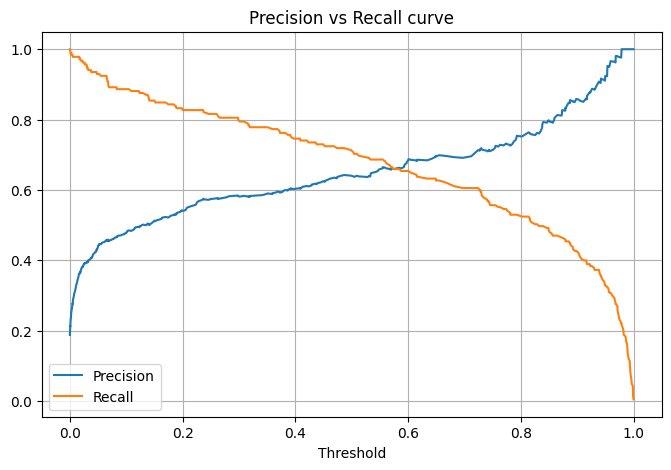

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, probs)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.title('Precision vs Recall curve')
plt.legend()
plt.grid()
plt.show()

# the plot indicates that that model reach an optimal balance at a treshold of approximately 0.58.
# At the default 0.5 threshold, recall is higher than precision, meaning the model is more likely to predict a positive class. In this configuration,
# model focus on not missing good movies.
# the higher the threshold, the more the model focuses on not predicing a bad movie a positive class

In [ ]:
probs = lgbm_final_model.predict_proba(x_test.drop(["movie_title", "movie_imdb_link"], axis=1))[:, 1]
new_preds = (probs >= 0.58).astype(int)
preds = (probs >= 0.5).astype(int)
print("Precision at 0.5 treshold: ", round(precision_score(y_test, preds),3),"\nRecall at 0.5 treshold: ", round(recall_score(y_test, preds),3))
print("Precision at 0.58 treshold: ", round(precision_score(y_test, new_preds),3), "\nRecall at 0.58 treshold: ", round(recall_score(y_test, new_preds),3))

Precision at 0.5 treshold:  0.639 
Recall at 0.5 treshold:  0.708
Precision at 0.58 treshold:  0.663 
Recall at 0.58 treshold:  0.659


In [ ]:
# We adjusted the decision threshold from the default 0.5 to 0.58 to achieve a perfect balance between precision and recall.

In [ ]:
lgbm_test_preds = (lgbm_final_model.predict_proba(x_test.drop(["movie_title", "movie_imdb_link"], axis=1)) >= 0.58)[:,1].astype(int)
print("-----Error analysis-----")
print("Number of instances where imdb_score >= 7.5 (postive calss): ", len(x_test.iloc[1 == y_test, :]))
print("Number of correct predictions: ", len(x_test.iloc[lgbm_test_preds == y_test, :])) 
print("Number of incorrect prediciotns: ", len(x_test.iloc[lgbm_test_preds != y_test, :])) 
print("Number of incorrect predictions where imdb score was betwwen 7 and 8: ", len(x_test.iloc[(lgbm_test_preds != y_test) & ((x_test.imdb_score >= 7)  & (x_test.imdb_score <= 8)), :]))
print("Number of incorrect predicitons where imdb score > 8: ",len(x_test.iloc[(lgbm_test_preds != y_test) & (x_test.imdb_score > 8), :]))
print("Number of incorrect predicions where imdb score < 7: ", len(x_test.iloc[(lgbm_test_preds != y_test) & (x_test.imdb_score < 7), :]))
print("Number of instances where imdb score was betwwen 7 and 8: ", len(x_test.iloc[((x_test.imdb_score >= 7)  & (x_test.imdb_score <= 8)), :]))

-----Error analysis-----
Number of instances where imdb_score >= 7.5 (postive calss):  185
Number of correct predictions:  859
Number of incorrect prediciotns:  125
Number of incorrect predictions where imdb score was betwwen 7 and 8:  107
Number of incorrect predicitons where imdb score > 8:  6
Number of incorrect predicions where imdb score < 7:  12
Number of instances where imdb score was betwwen 7 and 8:  304


#### Key Performance conclusions
The final model achieved an F1-score of approximately 66%. This metric provides a balanced view of the model's performance by aggregating Precision and Recall, where:
- Precision represents the reliability of our predictions (how often the model is correct when it flags movie as a hit).
- Recall reflects the model's 'capture rate' (what percentage of hit movies we successfully identified).

It means that we catch most good movies, but we stay careful not to choose too many low-rated ones. There is possibility to adjust the model to fit business goals. For example, we can prioritize finding more hits, even if it results in selecting more low-rated movies by mistake. We can also do the opposite if there is need to be more strict. 

Approximately 86% of errors occur when actual IMDB scores was between 7 and 8. The model is most reliable at the extremes of the imdb scale, achieving a success rate of over 97% for movies rated below 7.0 or above 8.0.